# Solución del Laboratorio de Desafío

# Problema: Predicción de Retrasos en Vuelos

Los objetivos múltiples de este notebook son:
- Procesar y crear un conjunto de datos a partir de archivos ZIP descargados.
- Realizar un análisis exploratorio de datos (EDA).
- Establecer un modelo base.
- Pasar de un modelo simple a un modelo de ensamblaje.
- Optimización de hiperparámetros.
- Revisar la importancia de las características.

## Introducción al escenario de negocio
Trabajas para un sitio web de reservas de viajes que busca mejorar la experiencia del cliente en vuelos retrasados. La empresa quiere crear una funcionalidad que informe a los clientes si un vuelo se retrasará debido al clima cuando reserven vuelos hacia o desde los aeropuertos más concurridos de los Estados Unidos.

Se te asignó resolver parte de este problema aprovechando **machine learning** para identificar si un vuelo se retrasará debido al clima. Se te proporcionó un conjunto de datos sobre el desempeño puntual de vuelos nacionales operados por grandes aerolíneas. Puedes usar estos datos para entrenar un modelo de aprendizaje automático que prediga si un vuelo se retrasará en los aeropuertos más ocupados.

## Sobre este conjunto de datos
Este conjunto de datos contiene horarios programados y reales de salida y llegada reportados por aerolíneas certificadas en los EE.UU. que representan al menos el 1% de los ingresos por pasajeros programados a nivel nacional. Los datos fueron recopilados por la Oficina de Información de Aerolíneas, Oficina de Estadísticas de Transporte (BTS). El conjunto de datos incluye fecha, hora, origen, destino, aerolínea, distancia y estado de retraso de vuelos realizados entre 2013 y 2018.

### Características
Para más información sobre las características del conjunto de datos, consulta [Características del conjunto de datos de retrasos en vuelos](https://www.transtats.bts.gov/Fields.asp).

### Atribución del conjunto de datos
Sitio web: https://www.transtats.bts.gov/

El(los) conjunto(s) de datos utilizado(s) en este laboratorio fueron compilados por la Oficina de Información de Aerolíneas, Oficina de Estadísticas de Transporte (BTS), Datos de Desempeño Puntual de Aerolíneas, disponibles en https://www.transtats.bts.gov/DatabaseInfo.asp?DB_ID=120&DB_URL=Mode_ID=1&Mode_Desc=Aviation&Subject_ID2=0.


# Paso 1: Formulación del problema y recolección de datos

Comienza este proyecto escribiendo algunas oraciones que resuman el problema de negocio y el objetivo empresarial que buscas lograr en este escenario. Incluye una métrica empresarial hacia la cual tú o tu equipo deberían aspirar. Con esa información definida, redacta claramente el enunciado del problema de aprendizaje automático. Finalmente, agrega uno o dos comentarios sobre el tipo de aprendizaje automático que esto representa.

#### <span style="color: blue;">Presentación del proyecto: Incluye un resumen de estos detalles en tus presentaciones de proyecto.</span>

### 1. Determina si el aprendizaje automático es una solución adecuada y por qué.
\# Escribe tu respuesta aquí

### 2. Formula el problema de negocio, las métricas de éxito y la salida deseada del aprendizaje automático.
\# Escribe tu respuesta aquí

### 3. Identifica el tipo de problema de aprendizaje automático con el que estás trabajando.
\# Escribe tu respuesta aquí

### 4. Analiza la idoneidad de los datos con los que estás trabajando.
\# Escribe tu respuesta aquí


### Configuración

Ahora que hemos decidido dónde enfocarnos, configuraremos todo para que puedas comenzar a trabajar en la solución del problema.

**Nota:** Este notebook fue creado y probado en una instancia de notebook `ml.t2.medium` con 25GB de almacenamiento.


In [191]:
# Importamos las bibliotecas necesarias
import os  # Manejo de operaciones del sistema operativo, como rutas de archivos
from pathlib2 import Path  # Manejo flexible de rutas de archivos y directorios
from zipfile import ZipFile  # Para trabajar con archivos comprimidos en formato ZIP
import time  # Manejo de funciones relacionadas con el tiempo, como medir tiempos de ejecución

import pandas as pd  # Biblioteca para trabajar con datos tabulares (DataFrames)
import numpy as np  # Operaciones matemáticas y manipulación de matrices

import matplotlib.pyplot as plt  # Biblioteca para generar gráficos básicos
import seaborn as sns  # Biblioteca para crear gráficos avanzados y personalizados

sns.set()  # Configuramos un estilo predeterminado para los gráficos
instance_type = 'ml.m4.4xlarge'  # Tipo de instancia a usar para ejecutar el modelo en SageMaker

import warnings  # Para manejar advertencias durante la ejecución
warnings.filterwarnings('ignore')  # Ignoramos advertencias para mantener limpio el output

# Garantiza que los gráficos se rendericen directamente en el notebook
%matplotlib inline 

# Paso 2: Preprocesamiento y visualización de datos

En esta fase de preprocesamiento de datos, debes aprovechar la oportunidad para explorar y visualizar los datos para comprenderlos mejor. Primero, importa las bibliotecas necesarias y carga los datos en un DataFrame de Pandas. Después de eso, explora los datos. Observa la forma del conjunto de datos y examina las columnas, así como los tipos de datos con los que estás trabajando (numéricos, categóricos). Considera realizar estadísticas básicas sobre las características para comprender los promedios y rangos de las variables. Examina detenidamente la columna objetivo y determina su distribución.

### Preguntas específicas a considerar
1. ¿Qué puedes deducir de las estadísticas básicas realizadas sobre las características?

2. ¿Qué puedes deducir de las distribuciones de las clases objetivo?

3. ¿Hay algo más que hayas deducido al explorar los datos?

#### <span style="color: blue;">Presentación del proyecto: Incluye un resumen de tus respuestas a estas y otras preguntas similares en tus presentaciones de proyecto.</span>


Comience por incorporar el conjunto de datos de un depósito público de Amazon S3 a este entorno de notebook.

In [192]:
# Definimos la ruta donde se almacenarán los archivos ZIP descargados
zip_path = '/home/ec2-user/SageMaker/project/data/FlightDelays/'

# Definimos la ruta base del proyecto, donde se organizarán otros datos relacionados
base_path = '/home/ec2-user/SageMaker/project/data/'

# Definimos la ruta donde se extraerán y guardarán los archivos CSV descomprimidos
csv_base_path = '/home/ec2-user/SageMaker/project/data/csvFlightDelays/'

# Creamos el directorio para los archivos ZIP si no existe, utilizando un comando de shell
!mkdir -p {zip_path}

# Creamos el directorio para los archivos CSV si no existe, utilizando un comando de shell
!mkdir -p {csv_base_path}

# Descargamos los archivos desde un bucket de S3 al directorio especificado de forma recursiva
# - "s3 cp" es el comando para copiar archivos desde S3.
# - La fuente es un bucket público de AWS con los datos del proyecto.
# - "{zip_path}" es el destino local donde se guardarán los archivos ZIP descargados.
!aws s3 cp s3://aws-tc-largeobjects/CUR-TF-200-ACAIML-1/flight_delay_project/data/ {zip_path} --recursive


download: s3://aws-tc-largeobjects/CUR-TF-200-ACAIML-1/flight_delay_project/data/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2014_1.zip to project/data/FlightDelays/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2014_1.zip
download: s3://aws-tc-largeobjects/CUR-TF-200-ACAIML-1/flight_delay_project/data/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2014_2.zip to project/data/FlightDelays/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2014_2.zip
download: s3://aws-tc-largeobjects/CUR-TF-200-ACAIML-1/flight_delay_project/data/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2014_10.zip to project/data/FlightDelays/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2014_10.zip
download: s3://aws-tc-largeobjects/CUR-TF-200-ACAIML-1/flight_delay_project/data/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2014_11.zip to project/data/FlightDelays/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2014_11.

In [193]:
# Obtenemos una lista de todos los archivos en la carpeta definida en zip_path
# Utilizamos la función Path.iterdir() para iterar a través de todos los elementos en zip_path
# Convertimos cada archivo en una cadena (str) para manipularlo como texto
# Filtramos los archivos que tienen la extensión '.zip' para incluir solo archivos ZIP en la lista
zip_files = [str(file) for file in list(Path(zip_path).iterdir()) if '.zip' in str(file)]

# Calculamos la longitud de la lista zip_files para contar cuántos archivos ZIP se encontraron
len(zip_files)


60

#### Extraer archivos CSV de archivos ZIP

In [194]:
# Definimos una función para extraer archivos CSV desde un archivo ZIP
def zip2csv(zipFile_name, file_path):
    """
    Extrae archivos CSV desde un archivo ZIP.
    zipFile_name: nombre del archivo ZIP a procesar.
    file_path: ruta de la carpeta donde se almacenarán los archivos extraídos.
    """
    try:
        # Intentamos abrir el archivo ZIP en modo de solo lectura ('r')
        with ZipFile(zipFile_name, 'r') as z: 
            print(f'Extracting {zipFile_name}')  # Mensaje para mostrar qué archivo se está procesando
            # Extraemos todo el contenido del archivo ZIP en la carpeta especificada por file_path
            z.extractall(path=file_path) 
    except:
        # Si algo falla, mostramos un mensaje de error indicando el archivo que causó el problema
        print(f'zip2csv failed for {zipFile_name}')

# Iteramos a través de la lista de archivos ZIP identificados anteriormente
for file in zip_files:
    # Llamamos a la función zip2csv para extraer cada archivo ZIP en la ruta csv_base_path
    zip2csv(file, csv_base_path)

# Mensaje final para indicar que todos los archivos han sido extraídos correctamente
print("Files Extracted")


Extracting /home/ec2-user/SageMaker/project/data/FlightDelays/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2015_9.zip
Extracting /home/ec2-user/SageMaker/project/data/FlightDelays/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2018_6.zip
Extracting /home/ec2-user/SageMaker/project/data/FlightDelays/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2015_2.zip
Extracting /home/ec2-user/SageMaker/project/data/FlightDelays/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2017_6.zip
Extracting /home/ec2-user/SageMaker/project/data/FlightDelays/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2014_8.zip
Extracting /home/ec2-user/SageMaker/project/data/FlightDelays/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2018_4.zip
Extracting /home/ec2-user/SageMaker/project/data/FlightDelays/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2015_12.zip
Extracting /home/ec2-user/SageMaker/project/data/FlightDelays/On_Time_Repor

In [195]:
# Creamos una lista que contendrá las rutas de todos los archivos CSV encontrados en la carpeta csv_base_path
csv_files = [str(file) for file in list(Path(csv_base_path).iterdir()) if '.csv' in str(file)]

# Mostramos la cantidad de archivos CSV encontrados en la carpeta
len(csv_files)


60

Antes de cargar el archivo CSV, lee el archivo HTML desde la carpeta extraída. Este archivo HTML incluye información de fondo y más detalles sobre las características incluidas en el conjunto de datos.

In [196]:
from IPython.display import IFrame, HTML  # Importamos herramientas para mostrar contenido HTML en el notebook

# Mostramos el archivo HTML "readme.html" en un IFrame para facilitar su visualización
IFrame(src=os.path.relpath(f"{csv_base_path}readme.html"), width=1000, height=600)


#### Cargar un CSV de ejemplo

Antes de combinar todos los archivos CSV, analiza un archivo CSV individual para tener una idea de los datos. Usando Pandas, primero lee el archivo `On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2018_9.csv`. Puedes utilizar la función integrada de Python `read_csv` ([documentación](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html)).


In [197]:
# Leer un archivo CSV de ejemplo utilizando Pandas
df_temp = pd.read_csv(f"{csv_base_path}On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2018_9.csv")


**Pregunta**: Imprime la cantidad de filas y columnas en el conjunto de datos e imprime los nombres de las columnas.

**Pista**: Utiliza la función `<dataframe>.shape` para ver las filas y columnas de un dataframe y `<dataframe>.columns` para ver los nombres de las columnas.


In [198]:
# Obtenemos la cantidad de filas y columnas del archivo CSV utilizando la propiedad shape
df_shape = df_temp.shape

# Imprimimos el número de filas y columnas en el archivo CSV
print(f'Rows and columns in one csv file is {df_shape}')


Rows and columns in one csv file is (585749, 110)


**Pregunta**: Imprime las primeras 10 filas del conjunto de datos.

**Pista**: Utiliza la función incorporada de Pandas `head(x)` para imprimir `x` número de filas.


In [199]:
# Mostramos las primeras 10 filas del conjunto de datos utilizando la función head
df_temp.head(10)


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,...,Div4TailNum,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Unnamed: 109
0,2018,3,9,3,1,2018-09-03,9E,20363,9E,N908XJ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018,3,9,9,7,2018-09-09,9E,20363,9E,N315PQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2018,3,9,10,1,2018-09-10,9E,20363,9E,N582CA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018,3,9,13,4,2018-09-13,9E,20363,9E,N292PQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018,3,9,14,5,2018-09-14,9E,20363,9E,N600LR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2018,3,9,16,7,2018-09-16,9E,20363,9E,N316PQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2018,3,9,17,1,2018-09-17,9E,20363,9E,N916XJ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2018,3,9,20,4,2018-09-20,9E,20363,9E,N371CA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2018,3,9,21,5,2018-09-21,9E,20363,9E,N601LR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2018,3,9,23,7,2018-09-23,9E,20363,9E,N906XJ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Pregunta**: Imprime todas las columnas del conjunto de datos. Usa `<dataframe>.columns` para ver los nombres de las columnas.


In [200]:
# Imprimimos un encabezado para indicar que listaremos las columnas
print(f'The column names are :')
print('#########')

# Iteramos a través de las columnas del DataFrame e imprimimos cada nombre de columna
for col in df_temp.columns:
    print(col)


The column names are :
#########
Year
Quarter
Month
DayofMonth
DayOfWeek
FlightDate
Reporting_Airline
DOT_ID_Reporting_Airline
IATA_CODE_Reporting_Airline
Tail_Number
Flight_Number_Reporting_Airline
OriginAirportID
OriginAirportSeqID
OriginCityMarketID
Origin
OriginCityName
OriginState
OriginStateFips
OriginStateName
OriginWac
DestAirportID
DestAirportSeqID
DestCityMarketID
Dest
DestCityName
DestState
DestStateFips
DestStateName
DestWac
CRSDepTime
DepTime
DepDelay
DepDelayMinutes
DepDel15
DepartureDelayGroups
DepTimeBlk
TaxiOut
WheelsOff
WheelsOn
TaxiIn
CRSArrTime
ArrTime
ArrDelay
ArrDelayMinutes
ArrDel15
ArrivalDelayGroups
ArrTimeBlk
Cancelled
CancellationCode
Diverted
CRSElapsedTime
ActualElapsedTime
AirTime
Flights
Distance
DistanceGroup
CarrierDelay
WeatherDelay
NASDelay
SecurityDelay
LateAircraftDelay
FirstDepTime
TotalAddGTime
LongestAddGTime
DivAirportLandings
DivReachedDest
DivActualElapsedTime
DivArrDelay
DivDistance
Div1Airport
Div1AirportID
Div1AirportSeqID
Div1WheelsOn
Div1

**Pregunta**: Imprime todas las columnas del conjunto de datos que contienen la palabra 'Del'. Esto te ayudará a ver cuántas columnas tienen datos relacionados con retrasos.

**Pista**: Puedes usar una lista por comprensión en Python para incluir valores que cumplan ciertos criterios con un `if`.

Por ejemplo: `[x for x in [1,2,3,4,5] if x > 2]`

**Pista**: Puedes usar la palabra clave `in` ([documentación](https://www.w3schools.com/python/ref_keyword_in.asp)) para verificar si un valor está en una lista o no.

Por ejemplo: `5 in [1,2,3,4,5]`


In [201]:
# Usamos una lista por comprensión para filtrar los nombres de columnas que contienen la palabra 'Del'
[col for col in df_temp.columns if 'Del' in col]


['DepDelay',
 'DepDelayMinutes',
 'DepDel15',
 'DepartureDelayGroups',
 'ArrDelay',
 'ArrDelayMinutes',
 'ArrDel15',
 'ArrivalDelayGroups',
 'CarrierDelay',
 'WeatherDelay',
 'NASDelay',
 'SecurityDelay',
 'LateAircraftDelay',
 'DivArrDelay']

Aquí tienes algunas preguntas más para ayudarte a conocer mejor tu conjunto de datos.

**Preguntas**   
1. ¿Cuántas filas y columnas tiene el conjunto de datos?   
2. ¿Cuántos años están incluidos en el conjunto de datos?   
3. ¿Cuál es el rango de fechas del conjunto de datos?   
4. ¿Qué aerolíneas están incluidas en el conjunto de datos?   
5. ¿Qué aeropuertos de origen y destino están cubiertos?


In [202]:
# Imprimimos la cantidad de filas y columnas en el conjunto de datos
print("The #rows and #columns are ", df_temp.shape[0], " and ", df_temp.shape[1])

# Mostramos los años únicos presentes en el conjunto de datos
print("The years in this dataset are: ", list(df_temp.Year.unique()))

# Mostramos los meses únicos, ordenados, que están cubiertos en el conjunto de datos
print("The months covered in this dataset are: ", sorted(list(df_temp.Month.unique())))

# Mostramos el rango de fechas en el conjunto de datos (mínima y máxima fecha)
print("The date range for data is :", min(df_temp.FlightDate), " to ", max(df_temp.FlightDate))

# Mostramos las aerolíneas únicas incluidas en el conjunto de datos
print("The airlines covered in this dataset are: ", list(df_temp.Reporting_Airline.unique()))

# Mostramos los aeropuertos de origen únicos presentes en el conjunto de datos
print("The Origin airports covered are: ", list(df_temp.Origin.unique()))

# Mostramos los aeropuertos de destino únicos presentes en el conjunto de datos
print("The Destination airports covered are: ", list(df_temp.Dest.unique()))


The #rows and #columns are  585749  and  110
The years in this dataset are:  [2018]
The months covered in this dataset are:  [9]
The date range for data is : 2018-09-01  to  2018-09-30
The airlines covered in this dataset are:  ['9E', 'B6', 'WN', 'YV', 'YX', 'EV', 'AA', 'AS', 'DL', 'HA', 'UA', 'F9', 'G4', 'MQ', 'NK', 'OH', 'OO']
The Origin airports covered are:  ['DFW', 'LGA', 'MSN', 'MSP', 'ATL', 'BDL', 'VLD', 'JFK', 'RDU', 'CHS', 'DTW', 'GRB', 'PVD', 'SHV', 'FNT', 'PIT', 'RIC', 'RST', 'RSW', 'CVG', 'LIT', 'ORD', 'JAX', 'TRI', 'BOS', 'CWA', 'DCA', 'CHO', 'AVP', 'IND', 'GRR', 'BTR', 'MEM', 'TUL', 'CLE', 'STL', 'BTV', 'OMA', 'MGM', 'TVC', 'SAV', 'GSP', 'EWR', 'OAJ', 'BNA', 'MCI', 'TLH', 'ROC', 'LEX', 'PWM', 'BUF', 'AGS', 'CLT', 'GSO', 'BWI', 'SAT', 'PHL', 'TYS', 'ACK', 'DSM', 'GNV', 'AVL', 'BGR', 'MHT', 'ILM', 'MOT', 'IAH', 'SBN', 'SYR', 'ORF', 'MKE', 'XNA', 'MSY', 'PBI', 'ABE', 'HPN', 'EVV', 'ALB', 'LNK', 'AUS', 'PHF', 'CHA', 'GTR', 'BMI', 'BQK', 'CID', 'CAK', 'ATW', 'ABY', 'CAE', 'SRQ

**Pregunta**: ¿Cuál es el conteo de todos los aeropuertos de origen y destino?

**Pista**: Puedes usar la función `value_counts` de Pandas ([documentación](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.value_counts.html)) para encontrar los valores de cada aeropuerto utilizando las columnas `Origin` y `Dest`.


In [203]:
# Creamos un DataFrame que contenga el conteo de aeropuertos de origen y destino
# Usamos value_counts para contar la frecuencia de cada aeropuerto en las columnas 'Origin' y 'Dest'
counts = pd.DataFrame({
    'Origin': df_temp['Origin'].value_counts(),  # Conteo de aeropuertos de origen
    'Destination': df_temp['Dest'].value_counts()  # Conteo de aeropuertos de destino
})

# Mostramos el DataFrame resultante con los conteos
counts


,Origin,Destination
ABE,303,303
ABI,169,169
ABQ,2077,2076
ABR,60,60
ABY,79,79
...,...,...
WRG,60,60
WYS,52,52
XNA,1004,1004
YAK,60,60


**Pregunta**: Imprime los 15 principales aeropuertos de origen y destino basados en el número de vuelos en el conjunto de datos.

**Pista**: Puedes usar la función `sort_values` de Pandas ([documentación](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sort_values.html)).


In [204]:
# Ordenamos el DataFrame 'counts' por la columna 'Origin' en orden descendente
# Mostramos los 15 principales aeropuertos de origen basados en el número de vuelos
counts.sort_values(by=['Origin'], ascending=False).head(15)


,Origin,Destination
ATL,31525,31521
ORD,28257,28250
DFW,22802,22795
DEN,19807,19807
CLT,19655,19654
LAX,17875,17873
SFO,14332,14348
IAH,14210,14203
LGA,13850,13850
MSP,13349,13347


**Pregunta**: Dada toda la información sobre un viaje en avión, ¿puedes predecir si se retrasará?


**Respuesta**: La columna **ArrDel15** es una variable indicadora que toma el valor 1 cuando el retraso es mayor a 15 minutos, y 0 en caso contrario.

Puedes usar esta columna como la variable objetivo para el problema de clasificación.


Ahora, supongamos que estás viajando de San Francisco a Los Ángeles en un viaje de trabajo. Quieres tener una idea de si tu vuelo se retrasará, dado un conjunto de características, para poder gestionar mejor tus reservas en Los Ángeles. ¿Cuántas características de este conjunto de datos conocerías antes de tu vuelo?

Columnas como `DepDelay`, `ArrDelay`, `CarrierDelay`, `WeatherDelay`, `NASDelay`, `SecurityDelay`, `LateAircraftDelay` y `DivArrDelay` contienen información sobre un retraso. Sin embargo, este retraso podría haber ocurrido en el origen o destino. Si hubiera un retraso climático repentino 10 minutos antes del aterrizaje, estos datos no serían útiles para gestionar tus reservas en Los Ángeles.

Para simplificar el planteamiento del problema, considera las siguientes columnas para predecir un retraso en la llegada:<br>

`Year`, `Quarter`, `Month`, `DayofMonth`, `DayOfWeek`, `FlightDate`, `Reporting_Airline`, `Origin`, `OriginState`, `Dest`, `DestState`, `CRSDepTime`, `DepDelayMinutes`, `DepartureDelayGroups`, `Cancelled`, `Diverted`, `Distance`, `DistanceGroup`, `ArrDelay`, `ArrDelayMinutes`, `ArrDel15`, `AirTime`

También filtrarás los aeropuertos de origen y destino para que sean:
- Aeropuertos principales: ATL, ORD, DFW, DEN, CLT, LAX, IAH, PHX, SFO
- Las 5 aerolíneas principales: UA, OO, WN, AA, DL

Esto debería ayudar a reducir el tamaño de los datos entre los archivos CSV que se combinarán.


#### Combina todos los archivos CSV

**Pista**:  
Primero, crea un DataFrame vacío que utilizarás para copiar los DataFrames individuales desde cada archivo. Luego, para cada archivo en la lista `csv_files`:

1. Lee el archivo CSV en un DataFrame.  
2. Filtra las columnas usando la variable `filter_cols`.

    columns = ['col1', 'col2']
    df_filter = df[columns]

3. Mantén solo los valores de `subset_vals` en cada una de las columnas de `subset_cols`. Usa la función `isin` de Pandas ([documentación](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.isin.html)) para verificar si un valor específico está en la columna del DataFrame y luego selecciona las filas que lo incluyan.

    df_eg[df_eg['col1'].isin('5')]

4. Concatena el DataFrame filtrado con el DataFrame vacío.


In [205]:
def combine_csv(csv_files, filter_cols, subset_cols, subset_vals, file_name):
    """
    Combina archivos CSV en un único DataFrame.
    csv_files: lista de rutas de los archivos CSV.
    filter_cols: lista de columnas a filtrar.
    subset_cols: lista de columnas para subestablecer filas.
    subset_vals: lista de listas con los valores para subestablecer filas.
    file_name: nombre del archivo donde se almacenará el CSV combinado.
    """

    # Creamos un DataFrame vacío donde se concatenarán los datos de los archivos
    df = pd.DataFrame()
    
    # Iteramos a través de cada archivo CSV en la lista csv_files
    for file in csv_files:
        # Leemos el archivo CSV actual en un DataFrame temporal
        df_temp = pd.read_csv(file)
        
        # Filtramos el DataFrame temporal para mantener solo las columnas especificadas en filter_cols
        df_temp = df_temp[filter_cols]
        
        # Iteramos a través de las columnas y valores para subestablecer las filas según subset_cols y subset_vals
        for col, val in zip(subset_cols, subset_vals):
            # Filtramos las filas donde los valores en la columna coinciden con los valores dados
            df_temp = df_temp[df_temp[col].isin(val)]      
        
        # Concatenamos el DataFrame temporal con el principal
        df = pd.concat([df, df_temp], axis=0)
      
    # Guardamos el DataFrame combinado en un archivo CSV
    df.to_csv(file_name, index=False)
    
    # Mostramos un mensaje indicando dónde se almacenó el archivo combinado
    print(f'Combined csv stored at {file_name}')


In [206]:
# Definimos las columnas que se utilizarán para predecir el retraso en la llegada
cols = ['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate',
        'Reporting_Airline', 'Origin', 'OriginState', 'Dest', 'DestState',
        'CRSDepTime', 'Cancelled', 'Diverted', 'Distance', 'DistanceGroup',
        'ArrDelay', 'ArrDelayMinutes', 'ArrDel15', 'AirTime']

# Definimos las columnas para subestablecer las filas en función de los valores específicos
subset_cols = ['Origin', 'Dest', 'Reporting_Airline']

# Definimos los valores principales de origen, destino y aerolíneas para filtrar los datos
subset_vals = [
    ['ATL', 'ORD', 'DFW', 'DEN', 'CLT', 'LAX', 'IAH', 'PHX', 'SFO'],  # Aeropuertos de origen
    ['ATL', 'ORD', 'DFW', 'DEN', 'CLT', 'LAX', 'IAH', 'PHX', 'SFO'],  # Aeropuertos de destino
    ['UA', 'OO', 'WN', 'AA', 'DL']  # Las 5 principales aerolíneas
]


Usa la función anterior para combinar todos los archivos diferentes en un único archivo que puedas leer fácilmente.

**Nota**: Esto tomará entre 5 y 7 minutos en completarse.


In [207]:
# Registramos el tiempo inicial para medir la duración del proceso
start = time.time()

# Definimos el nombre del archivo combinado donde se guardarán todos los datos procesados
combined_csv_filename = f"{base_path}combined_files.csv"

# Llamamos a la función combine_csv para combinar los archivos CSV en un único archivo
combine_csv(csv_files, cols, subset_cols, subset_vals, combined_csv_filename)

# Calculamos y mostramos el tiempo total que tomó el proceso en minutos
print(f'csv\'s merged in {round((time.time() - start)/60,2)} minutes')


Combined csv stored at /home/ec2-user/SageMaker/project/data/combined_files.csv
csv's merged in 5.35 minutes


#### Cargar el conjunto de datos

Cargar el conjunto de datos combinado.


In [208]:
# Cargar el archivo CSV combinado en un DataFrame de pandas
data = pd.read_csv(combined_csv_filename)


In [209]:
# Mostrar las primeras 5 filas del DataFrame
data.head(5)


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Origin,OriginState,Dest,DestState,CRSDepTime,Cancelled,Diverted,Distance,DistanceGroup,ArrDelay,ArrDelayMinutes,ArrDel15,AirTime
0,2014,1,1,26,7,2014-01-26,DL,ATL,GA,IAH,TX,2145,0.0,0.0,689.0,3,-20.0,0.0,0.0,99.0
1,2014,1,1,26,7,2014-01-26,DL,DFW,TX,ATL,GA,945,0.0,0.0,731.0,3,-3.0,0.0,0.0,98.0
2,2014,1,1,26,7,2014-01-26,DL,ATL,GA,DEN,CO,1855,0.0,0.0,1199.0,5,-7.0,0.0,0.0,174.0
3,2014,1,1,26,7,2014-01-26,DL,ATL,GA,PHX,AZ,1634,0.0,0.0,1587.0,7,-4.0,0.0,0.0,233.0
4,2014,1,1,26,7,2014-01-26,DL,PHX,AZ,ATL,GA,700,0.0,0.0,1587.0,7,-13.0,0.0,0.0,179.0


**Preguntas**  
1. ¿Cuántas filas y columnas tiene el conjunto de datos?  
2. ¿Cuántos años están incluidos en el conjunto de datos?  
3. ¿Cuál es el rango de fechas para el conjunto de datos?  
4. ¿Qué aerolíneas están incluidas en el conjunto de datos?  
5. ¿Qué aeropuertos de origen y destino están cubiertos?


Definamos nuestra **columna objetivo: is_delay** (1 - si el tiempo de llegada se retrasó más de 15 minutos, 0 - en caso contrario). Usa el método `rename` para cambiar el nombre de la columna de `ArrDel15` a `is_delay`.

**Sugerencia**: Puedes usar la función `rename` de Pandas ([documentación](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rename.html)).

Por ejemplo:
```python
# Cambiar el nombre de la columna 'ArrDel15' a 'is_delay'
df.rename(columns={'ArrDel15': 'is_delay'}, inplace=True)


In [210]:
# Cambiar el nombre de la columna 'ArrDel15' a 'is_delay'
data.rename(columns={'ArrDel15': 'is_delay'}, inplace=True)


Busca valores nulos a través de las columnas. Puedes usar la función `isnull()` ([documentación](https://pandas.pydata.org/pandas-docs/version/0.17.0/generated/pandas.isnull.html)).

**Sugerencia**: `isnull()` detecta si el valor particular es nulo o no y te devuelve un valor booleano (True o False) en su lugar. Usa la función `sum(axis=0)` para sumar el número de columnas.


In [211]:
data.head()

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Origin,OriginState,Dest,DestState,CRSDepTime,Cancelled,Diverted,Distance,DistanceGroup,ArrDelay,ArrDelayMinutes,is_delay,AirTime
0,2014,1,1,26,7,2014-01-26,DL,ATL,GA,IAH,TX,2145,0.0,0.0,689.0,3,-20.0,0.0,0.0,99.0
1,2014,1,1,26,7,2014-01-26,DL,DFW,TX,ATL,GA,945,0.0,0.0,731.0,3,-3.0,0.0,0.0,98.0
2,2014,1,1,26,7,2014-01-26,DL,ATL,GA,DEN,CO,1855,0.0,0.0,1199.0,5,-7.0,0.0,0.0,174.0
3,2014,1,1,26,7,2014-01-26,DL,ATL,GA,PHX,AZ,1634,0.0,0.0,1587.0,7,-4.0,0.0,0.0,233.0
4,2014,1,1,26,7,2014-01-26,DL,PHX,AZ,ATL,GA,700,0.0,0.0,1587.0,7,-13.0,0.0,0.0,179.0


In [212]:

# Detectar valores nulos en cada columna y contar el número de valores nulos por columna
data.isnull().sum(axis=0)

Year                     0
Quarter                  0
Month                    0
DayofMonth               0
DayOfWeek                0
FlightDate               0
Reporting_Airline        0
Origin                   0
OriginState              0
Dest                     0
DestState                0
CRSDepTime               0
Cancelled                0
Diverted                 0
Distance                 0
DistanceGroup            0
ArrDelay             22540
ArrDelayMinutes      22540
is_delay             22540
AirTime              22540
dtype: int64

Los detalles del retraso en la llegada y el tiempo de vuelo están faltando en 22,540 de 1,658,130 filas, lo que representa el 1.3%. Puedes eliminar o imputar estas filas. La documentación no menciona nada sobre las filas faltantes.

**Sugerencia**: Usa el operador `~` para elegir los valores que no son nulos a partir de la salida de `isnull()`.

Por ejemplo:
```python
# Filtrar las filas que no tienen valores nulos en la columna 'column_name'
null_eg = df_eg[~df_eg['column_name'].isnull()]


In [213]:
# Eliminar las filas con valores nulos en la columna 'is_delay'
data = data[~data.is_delay.isnull()]

# Comprobar cuántos valores nulos quedan en cada columna
data.isnull().sum(axis=0)


Year                 0
Quarter              0
Month                0
DayofMonth           0
DayOfWeek            0
FlightDate           0
Reporting_Airline    0
Origin               0
OriginState          0
Dest                 0
DestState            0
CRSDepTime           0
Cancelled            0
Diverted             0
Distance             0
DistanceGroup        0
ArrDelay             0
ArrDelayMinutes      0
is_delay             0
AirTime              0
dtype: int64

Obtén la hora del día en formato de 24 horas a partir de CRSDepTime.


In [214]:
# Crear una nueva columna 'DepHourofDay' con la hora del día extraída de 'CRSDepTime'
data['DepHourofDay'] = (data['CRSDepTime'] // 100)


## **El enunciado del problema de ML**
- Dado un conjunto de características, ¿puedes predecir si un vuelo se va a retrasar más de 15 minutos?
- Debido a que la variable objetivo toma solo valores 0/1, podrías utilizar un algoritmo de clasificación.

Antes de pasar al modelado, siempre es una buena práctica observar la distribución de características, correlaciones, etc.
- Esto te dará una idea de cualquier no linealidad/patrón en los datos.
    - Modelos lineales: Agregar características de potencia/exponenciales/interacción
    - Probar un modelo no lineal
- Desbalance de los datos
    - Elegir métricas que no den lugar a un rendimiento sesgado del modelo (precisión vs AUC)
    - Usar funciones de pérdida ponderadas o personalizadas
- Datos faltantes
    - Realizar imputación basada en estadísticas simples - media, mediana, moda (variables numéricas) clase frecuente (variables categóricas)
    - Imputación basada en agrupamiento (KNNs para predecir el valor de la columna)
    - Eliminar columna


### Exploración de datos

#### Verificar retraso de clase vs. sin retraso

**Sugerencia**: Usa un gráfico `groupby` ([documentación](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.groupby.html)) con un gráfico `bar` ([documentación](https://matplotlib.org/tutorials/introductory/pyplot.html)) para graficar la frecuencia vs. distribución de la clase.

```python
# Agrupar por la columna 'is_delay' y contar la frecuencia de cada clase, luego graficar un gráfico de barras
data.groupby('is_delay').size().plot(kind='bar', title='Distribución de retraso vs no retraso')


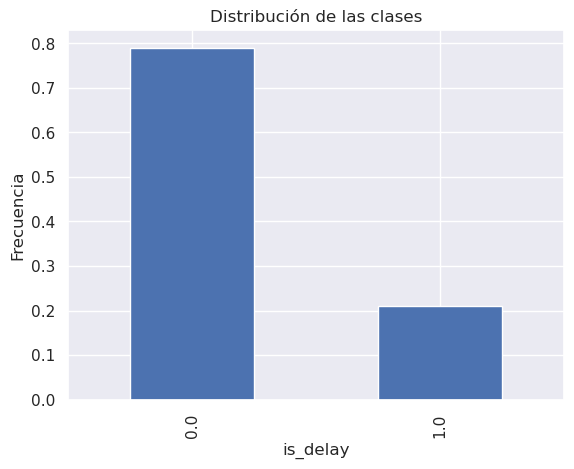

In [215]:
# Agrupar por la columna 'is_delay', calcular la frecuencia de cada clase como porcentaje y graficar un gráfico de barras
(data.groupby('is_delay').size() / len(data)).plot(kind='bar')

# Etiquetas del gráfico
plt.ylabel('Frecuencia')
plt.title('Distribución de las clases')
plt.show()


**Pregunta**: ¿Qué puedes deducir del gráfico de barras sobre la proporción de retrasos vs. sin retrasos?


**Respuesta:** El 80% de los vuelos llegan a tiempo, pero el 20% no lo hacen. Esto muestra un claro desbalance de clases.


**Preguntas**:

- ¿Qué meses tienen más retrasos?
- ¿Qué hora del día tiene más retrasos?
- ¿Qué día de la semana tiene más retrasos?
- ¿Qué aerolínea tiene más retrasos?
- ¿Qué aeropuertos de origen y destino tienen más retrasos?
- ¿Es la distancia del vuelo un factor en los retrasos?


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

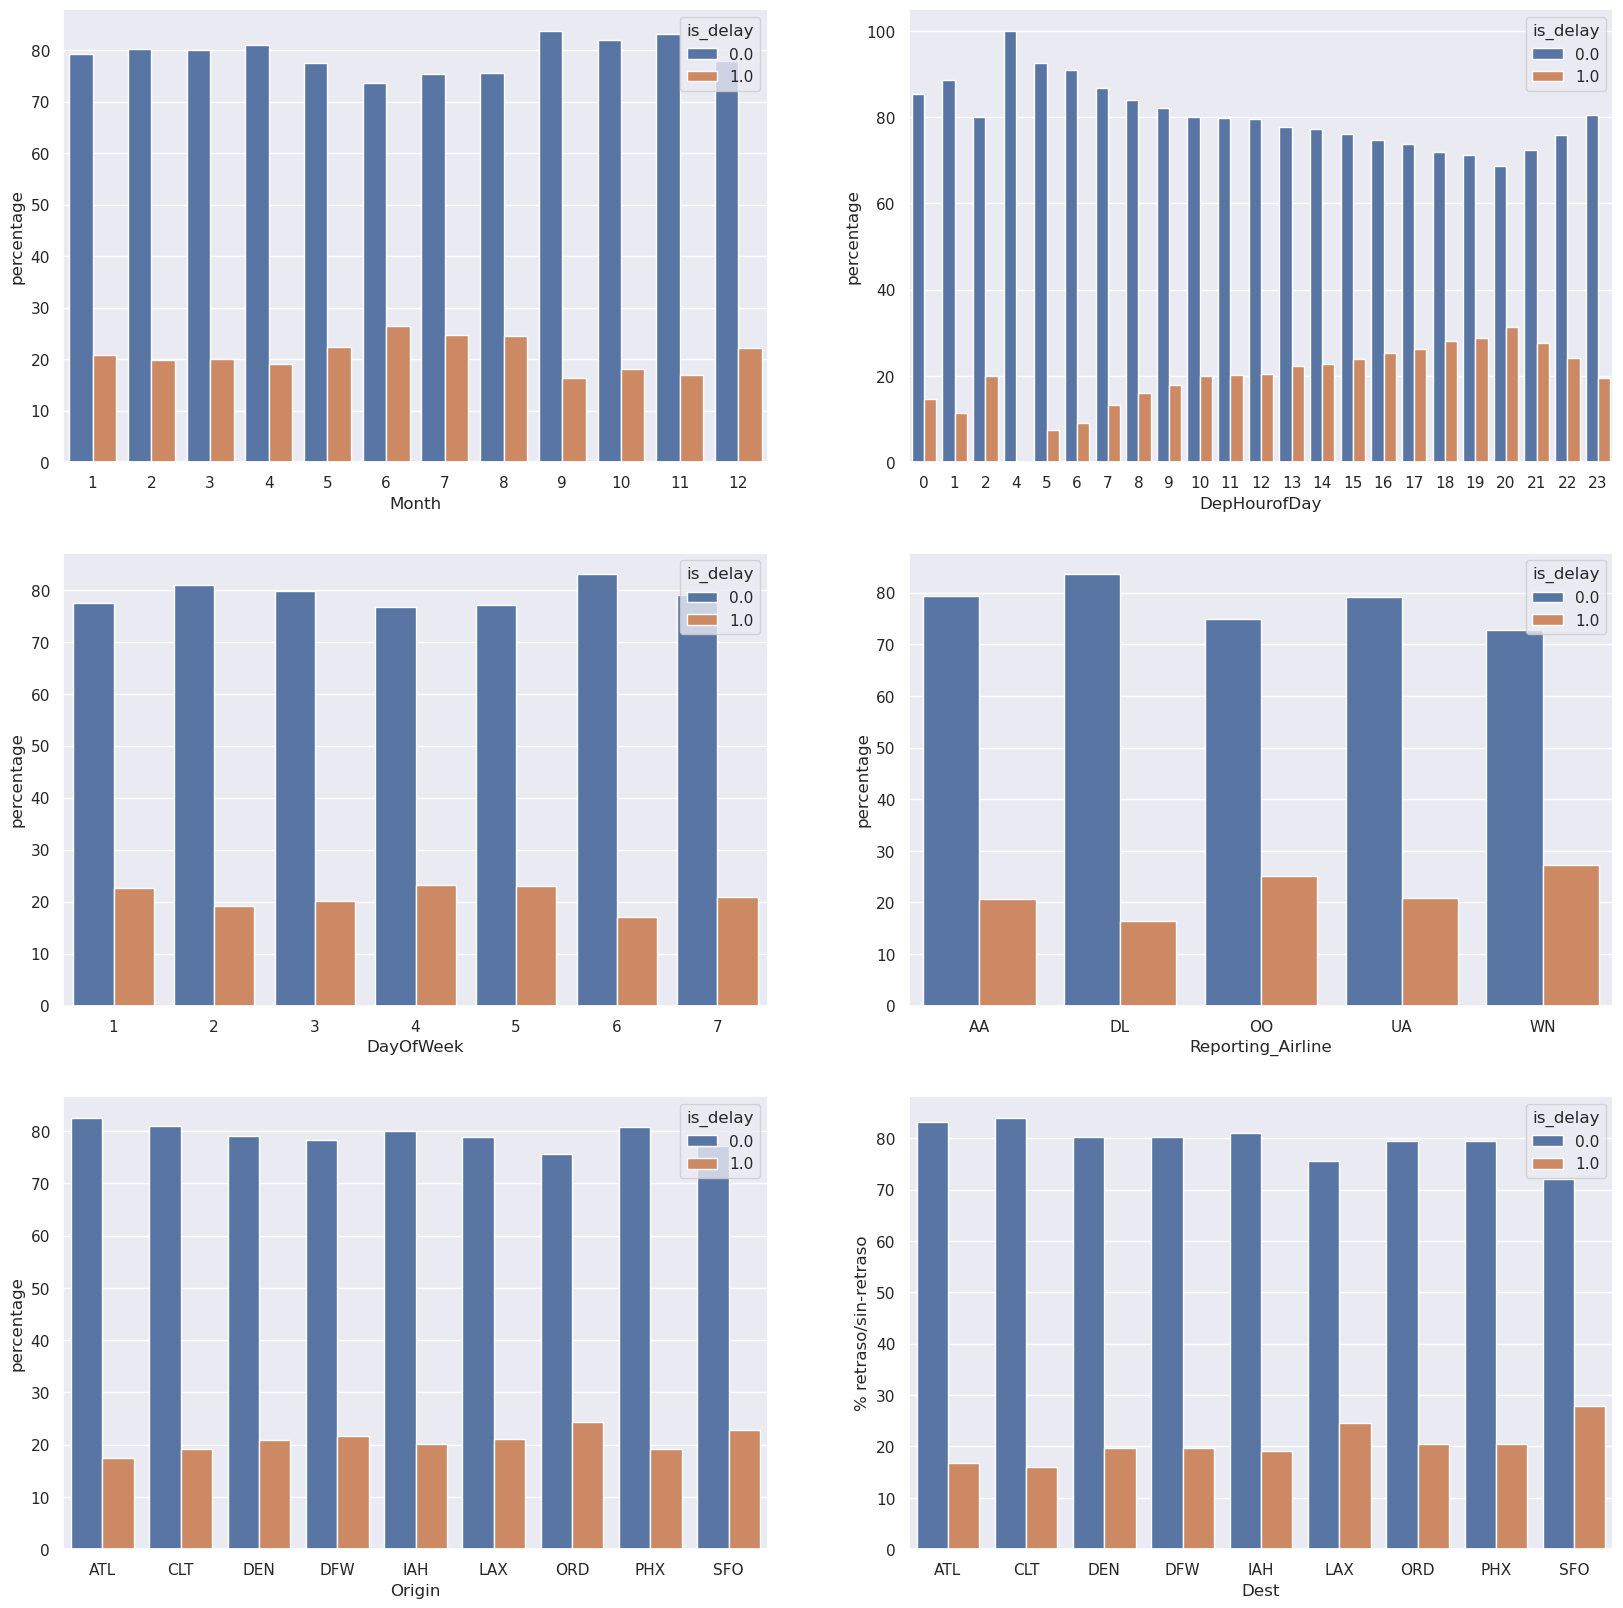

In [216]:
# Definir las columnas para la visualización
viz_columns = ['Month', 'DepHourofDay', 'DayOfWeek', 'Reporting_Airline', 'Origin', 'Dest']

# Crear una figura con 3 filas y 2 columnas de subgráficos
fig, axes = plt.subplots(3, 2, figsize=(20,20), squeeze=False)
# fig.autofmt_xdate(rotation=90)  # Descomentar si se quiere rotar las etiquetas del eje X

# Recorrer las columnas para graficar
for idx, column in enumerate(viz_columns):
    ax = axes[idx // 2, idx % 2]  # Determinar la posición del gráfico
    # Agrupar los datos por la columna, contar los retrasos/no retrasos, normalizar y convertir a porcentaje
    temp = data.groupby(column)['is_delay'].value_counts(normalize=True).rename('percentage').\
    mul(100).reset_index().sort_values(column)
    
    # Graficar un gráfico de barras para cada columna
    sns.barplot(x=column, y="percentage", hue="is_delay", data=temp, ax=ax)
    plt.ylabel('% retraso/sin-retraso')

# Mostrar los gráficos
plt.show()


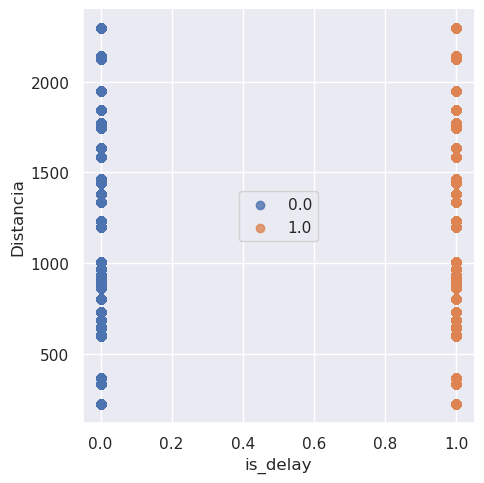

In [217]:
# Crear un gráfico de dispersión (scatter plot) para ver la relación entre 'is_delay' y 'Distance'
sns.lmplot(x="is_delay", y="Distance", data=data, fit_reg=False, hue='is_delay', legend=False)

# Configurar la leyenda y las etiquetas de los ejes
plt.legend(loc='center')
plt.xlabel('is_delay')
plt.ylabel('Distancia')

# Mostrar el gráfico
plt.show()


**Respuestas**
- Vemos que el % de retrasos es alto en mayo, junio, julio y agosto (meses 5-8).
- El % de retrasos es más alto por la noche que durante el día. ¡No hay vuelos saliendo a las 3 AM!
- El domingo (1), miércoles (4) y sábado (7) tienen un porcentaje de retrasos relativamente más alto que otros días.
- La aerolínea WN tiene el mayor % de retrasos en comparación con las demás.
- Los retrasos parecen ocurrir tanto en vuelos de corta como de larga distancia.
- Los vuelos con SFO como destino tienen más retrasos que otros.

Aunque algunas de las variables están codificadas con números, es importante considerarlas como variables categóricas porque no vemos una relación cuantitativa entre ellas y la variable objetivo.


### Características

Mira todas las columnas y cuáles son sus tipos específicos.


In [218]:
# Mostrar los nombres de todas las columnas en el DataFrame
data.columns

Index(['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate',
       'Reporting_Airline', 'Origin', 'OriginState', 'Dest', 'DestState',
       'CRSDepTime', 'Cancelled', 'Diverted', 'Distance', 'DistanceGroup',
       'ArrDelay', 'ArrDelayMinutes', 'is_delay', 'AirTime', 'DepHourofDay'],
      dtype='object')

In [219]:
# Mostrar los tipos de datos de todas las columnas en el DataFrame
data.dtypes


Year                   int64
Quarter                int64
Month                  int64
DayofMonth             int64
DayOfWeek              int64
FlightDate            object
Reporting_Airline     object
Origin                object
OriginState           object
Dest                  object
DestState             object
CRSDepTime             int64
Cancelled            float64
Diverted             float64
Distance             float64
DistanceGroup          int64
ArrDelay             float64
ArrDelayMinutes      float64
is_delay             float64
AirTime              float64
DepHourofDay           int64
dtype: object

Filtrando las columnas requeridas:
- La columna `Date` es redundante, ya que tienes `Year`, `Quarter`, `Month`, `DayofMonth` y `DayOfWeek` para describir la fecha.
- Usa los códigos de los aeropuertos `Origin` y `Dest` en lugar de `OriginState` y `DestState`.
- Debido a que solo estás clasificando si el vuelo está retrasado o no, no necesitas las columnas `TotalDelayMinutes`, `DepDelayMinutes` y `ArrDelayMinutes`.

Tratemos `DepHourofDay` como una variable categórica, porque no tiene ninguna relación cuantitativa con la variable objetivo.
- Si tuvieras que hacer un one-hot encoding de ella, resultaría en 23 columnas adicionales.
- Otras alternativas para manejar variables categóricas incluyen hash encoding, regularized mean encoding y bucketización de valores, entre otros.
- Aquí solo se dividirán los valores en "buckets".

**Sugerencia**: Para cambiar el tipo de una columna a categoría, usa la función `astype` ([documentación](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.astype.html)).


In [220]:
# Crear una copia original de los datos
data_orig = data.copy()

# Filtrar las columnas necesarias
data = data[['is_delay', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 
             'Reporting_Airline', 'Origin', 'Dest', 'Distance', 'DepHourofDay']]

# Definir las columnas categóricas
categorical_columns = ['Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 
                       'Reporting_Airline', 'Origin', 'Dest', 'DepHourofDay']

# Cambiar el tipo de las columnas categóricas a 'category'
for c in categorical_columns:
    data[c] = data[c].astype('category')


In [221]:
data.dtypes

is_delay              float64
Quarter              category
Month                category
DayofMonth           category
DayOfWeek            category
Reporting_Airline    category
Origin               category
Dest                 category
Distance              float64
DepHourofDay         category
dtype: object

Para usar one-hot encoding, utiliza la función `get_dummies` de Pandas para las columnas categóricas que seleccionaste anteriormente. Luego, puedes concatenar esas características generadas a tu conjunto de datos original usando la función `concat` de Pandas. Para codificar variables categóricas, también puedes usar *dummy encoding* utilizando el parámetro `drop_first=True`. Para más información sobre dummy encoding, consulta https://en.wikiversity.org/wiki/Dummy_variable_(statistics).

Por ejemplo:
```
pd.get_dummies(df[['column1','columns2']], drop_first=True)
```

In [222]:
# Aplicar one-hot encoding a las columnas categóricas y eliminar la primera columna de cada variable categórica
data_dummies = pd.get_dummies(data[categorical_columns], drop_first=True)

# Concatenar las columnas generadas por el one-hot encoding al conjunto de datos original
data = pd.concat([data, data_dummies], axis=1)

# Eliminar las columnas categóricas originales
data.drop(categorical_columns, axis=1, inplace=True)


In [223]:
data.dtypes

is_delay           float64
Distance           float64
Quarter_2            uint8
Quarter_3            uint8
Quarter_4            uint8
                    ...   
DepHourofDay_19      uint8
DepHourofDay_20      uint8
DepHourofDay_21      uint8
DepHourofDay_22      uint8
DepHourofDay_23      uint8
Length: 94, dtype: object

In [224]:
data.shape

(1635590, 94)

In [225]:
len(data)

1635590

In [226]:
data.columns

Index(['is_delay', 'Distance', 'Quarter_2', 'Quarter_3', 'Quarter_4',
       'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Month_7',
       'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12',
       'DayofMonth_2', 'DayofMonth_3', 'DayofMonth_4', 'DayofMonth_5',
       'DayofMonth_6', 'DayofMonth_7', 'DayofMonth_8', 'DayofMonth_9',
       'DayofMonth_10', 'DayofMonth_11', 'DayofMonth_12', 'DayofMonth_13',
       'DayofMonth_14', 'DayofMonth_15', 'DayofMonth_16', 'DayofMonth_17',
       'DayofMonth_18', 'DayofMonth_19', 'DayofMonth_20', 'DayofMonth_21',
       'DayofMonth_22', 'DayofMonth_23', 'DayofMonth_24', 'DayofMonth_25',
       'DayofMonth_26', 'DayofMonth_27', 'DayofMonth_28', 'DayofMonth_29',
       'DayofMonth_30', 'DayofMonth_31', 'DayOfWeek_2', 'DayOfWeek_3',
       'DayOfWeek_4', 'DayOfWeek_5', 'DayOfWeek_6', 'DayOfWeek_7',
       'Reporting_Airline_DL', 'Reporting_Airline_OO', 'Reporting_Airline_UA',
       'Reporting_Airline_WN', 'Origin_CLT', 'Origin_DEN',

Ahora estás listo para entrenar el modelo. Antes de dividir los datos, cambia el nombre de la columna `is_delay` a `target`.

**Sugerencia**: Puedes usar la función `rename` de Pandas ([documentación](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rename.html)).


In [227]:
data.rename(columns = {'is_delay':'target'}, inplace=True )

In [228]:
data.head(10)

,target,Distance,Quarter_2,Quarter_3,Quarter_4,Month_2,Month_3,Month_4,Month_5,Month_6,...,DepHourofDay_14,DepHourofDay_15,DepHourofDay_16,DepHourofDay_17,DepHourofDay_18,DepHourofDay_19,DepHourofDay_20,DepHourofDay_21,DepHourofDay_22,DepHourofDay_23
0,0.0,689.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0.0,731.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0.0,1199.0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0.0,1587.0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,0.0,1587.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0.0,226.0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
6,0.0,1199.0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
7,0.0,689.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0.0,226.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0.0,226.0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


# Project Solution Lab 3: 



# Paso 3: Entrenamiento y evaluación del modelo

Existen algunos pasos preliminares que debes incluir cuando conviertes el conjunto de datos de un dataframe a un formato que un algoritmo de aprendizaje automático pueda usar. Para Amazon SageMaker, estos son los pasos que necesitas seguir:

1. Divide los datos en `train_data`, `validation_data` y `test_data` usando `sklearn.model_selection.train_test_split`.
2. Convierte el conjunto de datos a un formato adecuado que el trabajo de entrenamiento de Amazon SageMaker pueda usar. Esto puede ser un archivo CSV o un registro protobuf. Para más información, consulta [Formatos de datos comunes para el entrenamiento](https://docs.aws.amazon.com/sagemaker/latest/dg/cdf-training.html).
3. Sube los datos a tu bucket de Amazon S3. Si no has creado uno antes, consulta [Crear un bucket](https://docs.aws.amazon.com/AmazonS3/latest/gsg/CreatingABucket.html).

Usa las celdas siguientes para completar estos pasos. Inserta y elimina celdas donde sea necesario.

#### <span style="color: blue;">Presentación del proyecto: Toma nota de las decisiones clave que has tomado en esta fase en la presentación de tu proyecto.</span>


### División de los datos en conjunto de entrenamiento y prueba


In [229]:
from sklearn.model_selection import train_test_split

# Función para dividir los datos en entrenamiento, validación y prueba
def split_data(data):
    # Dividir los datos en conjunto de entrenamiento y conjunto combinado de prueba y validación (80% entrenamiento, 20% prueba y validación)
    train, test_and_validate = train_test_split(data, test_size=0.2, random_state=42, stratify=data['target'])
    
    # Dividir el conjunto combinado de prueba y validación en prueba y validación (50% prueba, 50% validación)
    test, validate = train_test_split(test_and_validate, test_size=0.5, random_state=42, stratify=test_and_validate['target'])
    
    # Retornar los conjuntos de entrenamiento, validación y prueba
    return train, validate, test


In [230]:
# Dividir los datos en conjunto de entrenamiento, validación y prueba
train, validate, test = split_data(data)

# Imprimir la distribución de la variable 'target' en los conjuntos de entrenamiento, prueba y validación
print(train['target'].value_counts())
print(test['target'].value_counts())
print(validate['target'].value_counts())


0.0    1033806
1.0     274666
Name: target, dtype: int64
0.0    129226
1.0     34333
Name: target, dtype: int64
0.0    129226
1.0     34333
Name: target, dtype: int64


### Modelo de clasificación base


In [231]:
import sagemaker
from sagemaker.serializers import CSVSerializer
from sagemaker.amazon.amazon_estimator import RecordSet
import boto3

# Definir el tipo de instancia que vas a usar para el entrenamiento
instance_type = 'ml.m5.large'  # Ajusta esto al tipo de instancia que necesites

# Crear el estimador del clasificador con el modelo LinearLearner de SageMaker
classifier_estimator = sagemaker.LinearLearner(
    role=sagemaker.get_execution_role(),
    instance_count=1,  # Número de instancias de entrenamiento
    instance_type=instance_type,  # Tipo de instancia para el entrenamiento
    predictor_type='binary_classifier',  # Tipo de clasificador binario
    binary_classifier_model_selection_criteria='cross_entropy_loss'  # Criterio de selección del modelo (entropía cruzada)
)


El clasificador LinearLearner acepta datos de entrenamiento en formatos protobuf o CSV, y acepta solicitudes de inferencia en formatos protobuf, CSV o JSON. Los datos de entrenamiento contienen características y etiquetas de referencia (ground-truth), mientras que los datos en una solicitud de inferencia solo contienen características.

En una tubería de producción, se recomienda convertir los datos al formato protobuf de Amazon SageMaker y almacenarlos en Amazon S3. Sin embargo, para comenzar rápidamente, AWS proporciona el método conveniente `record_set` para convertir y cargar los datos cuando el conjunto de datos es lo suficientemente pequeño como para caber en la memoria local. Acepta matrices NumPy, como las que ya tienes, así que usémoslo aquí. El objeto `RecordSet` llevará un registro de la ubicación temporal en Amazon S3 de tus datos. Usa la función `estimator.record_set` para crear registros de entrenamiento, validación y prueba. Luego, usa la función `estimator.fit` para comenzar tu trabajo de entrenamiento.


### Crear registros de entrenamiento, validación y prueba

```python
train_records = classifier_estimator.record_set(train.values[:, 1:].astype(np.float32), train.values[:, 0].astype(np.float32), channel='train')
val_records = classifier_estimator.record_set(validate.values[:, 1:].astype(np.float32), validate.values[:, 0].astype(np.float32), channel='validation')
test_records = classifier_estimator.record_set(test.values[:, 1:].astype(np.float32), test.values[:, 0].astype(np.float32), channel='test')


In [232]:
### Ajustar el clasificador

classifier_estimator.fit([train_records, val_records, test_records])


INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: linear-learner-2024-11-27-16-03-10-496


2024-11-27 16:03:10 Starting - Starting the training job...
2024-11-27 16:03:32 Starting - Preparing the instances for training...
2024-11-27 16:03:56 Downloading - Downloading input data......
2024-11-27 16:04:52 Downloading - Downloading the training image......
2024-11-27 16:05:58 Training - Training image download completed. Training in progress.Docker entrypoint called with argument(s): train
Running default environment configuration script
[11/27/2024 16:06:03 INFO 140058845157184] Reading default configuration from /opt/amazon/lib/python3.8/site-packages/algorithm/resources/default-input.json: {'mini_batch_size': '1000', 'epochs': '15', 'feature_dim': 'auto', 'use_bias': 'true', 'binary_classifier_model_selection_criteria': 'accuracy', 'f_beta': '1.0', 'target_recall': '0.8', 'target_precision': '0.8', 'num_models': 'auto', 'num_calibration_samples': '10000000', 'init_method': 'uniform', 'init_scale': '0.07', 'init_sigma': '0.01', 'init_bias': '0.0', 'optimizer': 'auto', 'loss':

## Evaluación del modelo
En esta sección, evaluarás el modelo entrenado.


Primero, echa un vistazo a las métricas para el trabajo de entrenamiento:


In [233]:
# Crear un objeto TrainingJobAnalytics para obtener métricas del trabajo de entrenamiento
sagemaker.analytics.TrainingJobAnalytics(classifier_estimator._current_job_name,  # Nombre del trabajo de entrenamiento actual
                                         metric_names = ['test:objective_loss',  # Métrica de pérdida del objetivo en el conjunto de prueba
                                                         'test:binary_f_beta',  # Métrica F-beta binaria en el conjunto de prueba
                                                         'test:precision',  # Métrica de precisión en el conjunto de prueba
                                                         'test:recall']  # Métrica de recall en el conjunto de prueba
                                        ).dataframe()  # Convertir las métricas a un DataFrame para visualización


,timestamp,metric_name,value
0,0.0,test:objective_loss,0.481152
1,0.0,test:binary_f_beta,0.097067
2,0.0,test:precision,0.558104
3,0.0,test:recall,0.053156


In [238]:
import io
# Definir el nombre del bucket de S3 y los archivos que se van a subir
bucket = 'two-chickens'  # Nombre del bucket de S3
prefix = 'flight-linear'  # Prefijo de la carpeta en el bucket
train_file = 'flight_train.csv'  # Nombre del archivo de entrenamiento
test_file = 'flight_test.csv'  # Nombre del archivo de prueba
validate_file = 'flight_validate.csv'  # Nombre del archivo de validación
whole_file = 'flight.csv'  # Nombre del archivo completo
s3_resource = boto3.Session().resource('s3')  # Crear una sesión de boto3 para interactuar con S3

# Función para subir un archivo CSV a S3
def upload_s3_csv(filename, folder, dataframe):
    # Crear un buffer en memoria para escribir el CSV
    csv_buffer = io.StringIO()
    
    # Convertir el dataframe en un archivo CSV dentro del buffer
    dataframe.to_csv(csv_buffer, header=False, index=False)
    
    # Subir el contenido del buffer al bucket de S3 en la carpeta especificada
    s3_resource.Bucket(bucket).Object(os.path.join(prefix, folder, filename)).put(Body=csv_buffer.getvalue())


INFO:botocore.credentials:Found credentials from IAM Role: BaseNotebookInstanceEc2InstanceRole


Para ejecutar las predicciones en el conjunto de datos de prueba, ejecuta la función `batch_linear_predict` en tu conjunto de datos de prueba.


In [239]:
# Ejecutar la función 'batch_linear_predict' sobre el conjunto de prueba para obtener las etiquetas verdaderas y las predicciones
test_labels, target_predicted = batch_linear_predict(test, classifier_estimator)


NameError: name 'batch_linear_predict' is not defined

Para ver un gráfico de la matriz de confusión y varias métricas de puntuación, crea un par de funciones:


In [ ]:
from sklearn.metrics import confusion_matrix

# Función para graficar la matriz de confusión
def plot_confusion_matrix(test_labels, target_predicted):
    # Calcular la matriz de confusión
    matrix = confusion_matrix(test_labels, target_predicted)
    
    # Convertir la matriz en un DataFrame
    df_confusion = pd.DataFrame(matrix)
    
    # Definir el mapa de colores
    colormap = sns.color_palette("BrBG", 10)
    
    # Graficar la matriz de confusión
    sns.heatmap(df_confusion, annot=True, fmt='.2f', cbar=None, cmap=colormap)
    
    # Configurar el título y las etiquetas
    plt.title("Matriz de Confusión")
    plt.tight_layout()
    plt.ylabel("Clase Real")
    plt.xlabel("Clase Predicha")
    
    # Mostrar el gráfico
    plt.show()


In [ ]:
from sklearn import metrics

# Función para graficar la curva ROC y calcular las métricas asociadas
def plot_roc(test_labels, target_predicted):
    # Obtener los valores de la matriz de confusión
    TN, FP, FN, TP = confusion_matrix(test_labels, target_predicted).ravel()
    
    # Sensibilidad, tasa de verdaderos positivos o recall
    Sensitivity  = float(TP) / (TP + FN) * 100
    # Especificidad o tasa de verdaderos negativos
    Specificity  = float(TN) / (TN + FP) * 100
    # Precisión o valor predictivo positivo
    Precision = float(TP) / (TP + FP) * 100
    # Valor predictivo negativo
    NPV = float(TN) / (TN + FN) * 100
    # Tasa de falsos positivos
    FPR = float(FP) / (FP + TN) * 100
    # Tasa de falsos negativos
    FNR = float(FN) / (TP + FN) * 100
    # Tasa de descubrimiento falso
    FDR = float(FP) / (TP + FP) * 100
    # Precisión global
    ACC = float(TP + TN) / (TP + FP + FN + TN) * 100

    # Imprimir las métricas calculadas
    print("Sensitivity or TPR: ", Sensitivity, "%") 
    print("Specificity or TNR: ", Specificity, "%") 
    print("Precision: ", Precision, "%") 
    print("Negative Predictive Value: ", NPV, "%") 
    print("False Positive Rate: ", FPR, "%")
    print("False Negative Rate: ", FNR, "%") 
    print("False Discovery Rate: ", FDR, "%")
    print("Accuracy: ", ACC, "%") 

    # Calcular y mostrar el AUC de validación
    test_labels = test.iloc[:, 0]
    print("Validation AUC", metrics.roc_auc_score(test_labels, target_predicted))

    # Calcular la curva ROC
    fpr, tpr, thresholds = metrics.roc_curve(test_labels, target_predicted)
    roc_auc = metrics.auc(fpr, tpr)

    # Graficar la curva ROC
    plt.figure()
    plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % (roc_auc))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")

    # Crear el eje de los umbrales (scores)
    ax2 = plt.gca().twinx()
    ax2.plot(fpr, thresholds, markeredgecolor='r', linestyle='dashed', color='r')
    ax2.set_ylabel('Threshold', color='r')
    ax2.set_ylim([thresholds[-1], thresholds[0]])
    ax2.set_xlim([fpr[0], fpr[-1]])

    # Mostrar la figura
    print(plt.figure())


Para graficar la matriz de confusión, llama a la función `plot_confusion_matrix` sobre los datos `test_labels` y `target_predicted` de tu trabajo por lotes:


In [236]:
# Llamar a la función 'plot_confusion_matrix' para graficar la matriz de confusión con los datos de etiquetas de prueba y predicciones
plot_confusion_matrix(test_labels, target_predicted)


NameError: name 'plot_confusion_matrix' is not defined

### Preguntas clave a considerar:
1. ¿Cómo se compara el rendimiento de tu modelo en el conjunto de prueba con el del conjunto de entrenamiento? ¿Qué puedes deducir de esta comparación?

2. ¿Existen diferencias evidentes entre los resultados de métricas como precisión, recall y exactitud? Si es así, ¿por qué podrías estar viendo esas diferencias?

3. Dado tu contexto empresarial y objetivos, ¿qué métrica(s) es(n) más importante(s) para ti en este caso? ¿Por qué?

4. ¿Es el resultado de la(s) métrica(s) que consideras más importante suficiente para lo que necesitas desde el punto de vista empresarial? Si no es así, ¿qué cambios podrías realizar en tu próxima iteración (en la sección de ingeniería de características, que es la que sigue)?

Usa las celdas a continuación para responder a estas y otras preguntas. Inserta y elimina celdas según sea necesario.

#### <span style="color: blue;">Presentación del proyecto: Registra las respuestas a estas y otras preguntas similares que puedas responder en esta sección en tus presentaciones del proyecto. Registra los detalles clave y decisiones que has tomado en las presentaciones de tu proyecto.</span>


**Pregunta**: ¿Qué puedes resumir de la matriz de confusión?


#### Caso de desbalanceo de clases
- Al tratar con clases desbalanceadas, es importante considerar qué métrica optimizar para resolver el problema en cuestión.
- Puedes elegir precisión o recall, dependiendo de si solo las predicciones positivas correctas son importantes o si todas las predicciones positivas son lo más importante.
- También puedes equilibrar entre precisión y recall con pesos personalizados usando la puntuación F1-beta.

- AUC mide el área bajo la curva TPR vs. FPR. Es el poder del modelo para discriminar entre una predicción positiva y negativa.
- Un AUC de 0.5 significa que las predicciones del modelo son tan buenas como una predicción aleatoria.
- Ten en cuenta que AUC es independiente del umbral de precisión o recall, lo que facilita la comparación entre modelos.

Para el clasificador anterior, vemos que:
- Precisión ~ 80% y AUC ~0.5, lo que significa que el modelo no tiene suficiente poder predictivo y es tan bueno como una elección aleatoria.
- Los falsos negativos altos resultaron en un valor bajo de recall.

Para mejorar el rendimiento del clasificador, puedes:
- Agregar más características
- Optimizar para una métrica/pérdida diferente
- Probar modelos no lineales
- Hacer modelado en conjunto

Para más información sobre cómo personalizar el Linear Learner, consulta [Entrena modelos más rápidos y flexibles con Amazon SageMaker Linear Learner](https://aws.amazon.com/blogs/machine-learning/train-faster-more-flexible-models-with-amazon-sagemaker-linear-learner/).


# Solución del Proyecto Lab 4:


# Iteración II

# Paso 4: Ingeniería de características

Ahora has pasado por una iteración de entrenamiento y evaluación de tu modelo. Dado que el resultado que obtuviste para tu modelo la primera vez probablemente no fue suficiente para resolver tu problema empresarial, ¿qué cosas podrías cambiar sobre tus datos para mejorar el rendimiento del modelo?

### Preguntas clave a considerar:
1. ¿Cómo podría el balance de tus dos clases principales (retraso y no retraso) impactar el rendimiento del modelo?
2. ¿Tienes alguna característica que esté correlacionada?
3. ¿Existen técnicas de reducción de características que podrías realizar en esta etapa que podrían tener un impacto positivo en el rendimiento del modelo?
4. ¿Puedes pensar en agregar más datos/conjuntos de datos?
5. Después de realizar algo de ingeniería de características, ¿cómo se compara el rendimiento de tu modelo con la primera iteración?

Usa las celdas a continuación para realizar técnicas específicas de ingeniería de características (según las preguntas anteriores) que creas que podrían mejorar el rendimiento de tu modelo. Inserta y elimina celdas según sea necesario.

#### <span style="color: blue;">Presentación del proyecto: Registra las decisiones clave y los métodos que utilices en esta sección en tus presentaciones del proyecto, así como cualquier nueva métrica de rendimiento que obtengas después de evaluar nuevamente tu modelo.</span>

Antes de comenzar, piensa por qué la precisión y el recall están alrededor del 80% mientras que la exactitud es del 99%.


#### Agregar más características

1. Días festivos
2. Clima


Dado que la lista de feriados de 2014 a 2018 es conocida, puedes crear una variable indicadora **is_holiday** para marcar estos días.  
La hipótesis es que los retrasos de los aviones podrían ser mayores durante los feriados en comparación con el resto de los días. Agrega una variable booleana `is_holiday` que incluya los feriados para los años 2014-2018.

In [146]:
# Fuente de los feriados: http://www.calendarpedia.com/holidays/federal-holidays-2014.html

# Listas de feriados para los años 2014-2018
holidays_14 = ['2014-01-01',  '2014-01-20', '2014-02-17', '2014-05-26', '2014-07-04', '2014-09-01', '2014-10-13', '2014-11-11', '2014-11-27', '2014-12-25']
holidays_15 = ['2015-01-01',  '2015-01-19', '2015-02-16', '2015-05-25', '2015-06-03', '2015-07-04', '2015-09-07', '2015-10-12', '2015-11-11', '2015-11-26', '2015-12-25']
holidays_16 = ['2016-01-01',  '2016-01-18', '2016-02-15', '2016-05-30', '2016-07-04', '2016-09-05', '2016-10-10', '2016-11-11', '2016-11-24', '2016-12-25', '2016-12-26']
holidays_17 = ['2017-01-02', '2017-01-16', '2017-02-20', '2017-05-29' , '2017-07-04', '2017-09-04' ,'2017-10-09', '2017-11-10', '2017-11-23', '2017-12-25']
holidays_18 = ['2018-01-01', '2018-01-15', '2018-02-19', '2018-05-28' , '2018-07-04', '2018-09-03' ,'2018-10-08', '2018-11-12','2018-11-22', '2018-12-25']

# Combinar todos los feriados en una lista
holidays = holidays_14 + holidays_15 + holidays_16 + holidays_17 + holidays_18

# Agregar una variable indicadora 'is_holiday' para marcar los días feriados
data_orig['is_holiday'] = data_orig.FlightDate.isin(holidays).astype(int)


Los datos meteorológicos fueron obtenidos de [https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&stations=USW00023174,USW00012960,USW00003017,USW00094846,USW00013874,USW00023234,USW00003927,USW00023183,USW00013881&dataTypes=AWND,PRCP,SNOW,SNWD,TAVG,TMIN,TMAX&startDate=2014-01-01&endDate=2018-12-31](https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&stations=USW00023174,USW00012960,USW00003017,USW00094846,USW00013874,USW00023234,USW00003927,USW00023183,USW00013881&dataTypes=AWND,PRCP,SNOW,SNWD,TAVG,TMIN,TMAX&startDate=2014-01-01&endDate=2018-12-31).

Este conjunto de datos tiene información sobre velocidad del viento, precipitación, nieve y temperatura para ciudades según sus códigos de aeropuerto.

**Pregunta**: ¿Podría el mal tiempo debido a lluvias, vientos fuertes o nieve causar retrasos en los aviones? ¡Vamos a comprobarlo!


In [147]:
# Descargar el archivo CSV de datos meteorológicos desde S3 y guardarlo en el directorio local
!aws s3 cp s3://aws-tc-largeobjects/CUR-TF-200-ACAIML-1/flight_delay_project/data2/daily-summaries.csv /home/ec2-user/SageMaker/project/data/

# Alternativamente, si se quiere descargar directamente desde la URL proporcionada, descomentar la siguiente línea
#!wget 'https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&stations=USW00023174,USW00012960,USW00003017,USW00094846,USW00013874,USW00023234,USW00003927,USW00023183,USW00013881&dataTypes=AWND,PRCP,SNOW,SNWD,TAVG,TMIN,TMAX&startDate=2014-01-01&endDate=2018-12-31' -O /home/ec2-user/SageMaker/project/data/daily-summaries.csv


download: s3://aws-tc-largeobjects/CUR-TF-200-ACAIML-1/flight_delay_project/data2/daily-summaries.csv to project/data/daily-summaries.csv


Importa los datos meteorológicos preparados para los códigos de aeropuerto en nuestro conjunto de datos. Usa las estaciones y aeropuertos a continuación para el análisis, y crea una nueva columna llamada `airport` que mapea la estación meteorológica al nombre del aeropuerto.


In [149]:
# Cargar los datos meteorológicos desde el archivo CSV
weather = pd.read_csv('/home/ec2-user/SageMaker/project/data/daily-summaries.csv')

# Listado de estaciones y aeropuertos correspondientes
station = ['USW00023174','USW00012960','USW00003017','USW00094846','USW00013874','USW00023234','USW00003927','USW00023183','USW00013881'] 
airports = ['LAX', 'IAH', 'DEN', 'ORD', 'ATL', 'SFO', 'DFW', 'PHX', 'CLT']

# Mapear las estaciones meteorológicas a los códigos de los aeropuertos
station_map = {s: a for s, a in zip(station, airports)}

# Crear una nueva columna 'airport' que mapea la estación meteorológica al código de aeropuerto
weather['airport'] = weather['STATION'].map(station_map)


Crea otra columna llamada `MONTH` a partir de la columna `DATE`.


In [150]:
# Crear una nueva columna 'MONTH' extrayendo el mes de la columna 'DATE'
weather['MONTH'] = weather['DATE'].apply(lambda x: x.split('-')[1])

# Verificar los primeros registros para asegurar que la columna 'MONTH' se ha creado correctamente
weather.head()


,STATION,DATE,AWND,PRCP,SNOW,SNWD,TAVG,TMAX,TMIN,airport,MONTH
0,USW00023174,2014-01-01,16,0,NaN,NaN,131.0,178.0,78.0,LAX,01
1,USW00023174,2014-01-02,22,0,NaN,NaN,159.0,256.0,100.0,LAX,01
2,USW00023174,2014-01-03,17,0,NaN,NaN,140.0,178.0,83.0,LAX,01
3,USW00023174,2014-01-04,18,0,NaN,NaN,136.0,183.0,100.0,LAX,01
4,USW00023174,2014-01-05,18,0,NaN,NaN,151.0,244.0,83.0,LAX,01


Analiza y maneja las columnas `SNOW` y `SNWD` para los valores faltantes usando `fillna()`. Usa la función `isna()` para verificar los valores faltantes en todas las columnas.


In [151]:
# Rellenar los valores faltantes en las columnas 'SNOW' y 'SNWD' con 0, modificando el DataFrame original
weather.SNOW.fillna(0, inplace=True)
weather.SNWD.fillna(0, inplace=True)

# Verificar los valores faltantes después de aplicar el relleno
weather.isna().sum()


STATION     0
DATE        0
AWND        0
PRCP        0
SNOW        0
SNWD        0
TAVG       62
TMAX       20
TMIN       20
airport     0
MONTH       0
dtype: int64

**Pregunta**: Imprime el índice de las filas que tienen valores faltantes para `TAVG`, `TMAX`, `TMIN`.

**Sugerencia**: Usa la función `isna()` para encontrar las filas que faltan, y luego usa la lista en la variable `idx` para obtener el índice.


In [152]:
# Crear un array de índices para todas las filas del DataFrame 'weather'
idx = np.array([i for i in range(len(weather))])

# Obtener los índices de las filas donde la columna 'TAVG' tiene valores faltantes
TAVG_idx = idx[weather.TAVG.isna()]

# Obtener los índices de las filas donde la columna 'TMAX' tiene valores faltantes
TMAX_idx = idx[weather.TMAX.isna()]

# Obtener los índices de las filas donde la columna 'TMIN' tiene valores faltantes
TMIN_idx = idx[weather.TMIN.isna()]

# Imprimir los índices de las filas con valores faltantes en 'TAVG'
TAVG_idx


array([ 3956,  3957,  3958,  3959,  3960,  3961,  3962,  3963,  3964,
        3965,  3966,  3967,  3968,  3969,  3970,  3971,  3972,  3973,
        3974,  3975,  3976,  3977,  3978,  3979,  3980,  3981,  3982,
        3983,  3984,  3985,  4017,  4018,  4019,  4020,  4021,  4022,
        4023,  4024,  4025,  4026,  4027,  4028,  4029,  4030,  4031,
        4032,  4033,  4034,  4035,  4036,  4037,  4038,  4039,  4040,
        4041,  4042,  4043,  4044,  4045,  4046,  4047, 13420])

Puedes reemplazar los valores faltantes de `TAVG`, `TMAX` y `TMIN` con el valor promedio para una estación/aeropuerto particular. Debido a que las filas consecutivas de `TAVG_idx` están faltando, reemplazarlas con un valor previo no sería posible. En su lugar, reemplázalas con la media. Usa la función `groupby` para agregar las variables con un valor promedio.


In [153]:
# Agrupar por 'MONTH' y 'STATION' y calcular el promedio de las columnas 'TAVG', 'TMAX' y 'TMIN'
weather_impute = weather.groupby(['MONTH', 'STATION']).agg({'TAVG': 'mean', 'TMAX': 'mean', 'TMIN': 'mean'}).reset_index()

# Mostrar las primeras 2 filas del DataFrame con los valores promediados
weather_impute.head(2)


,MONTH,STATION,TAVG,TMAX,TMIN
0,01,USW00003017,-2.741935,74.000000,-69.858065
1,01,USW00003927,79.529032,143.767742,20.696774


Fusiona los datos promedio con los datos meteorológicos.


In [155]:
# Realizar una fusión de los datos promedio con los datos meteorológicos
weather = pd.merge(weather, weather_impute, how='left', left_on=['MONTH', 'STATION'], right_on=['MONTH', 'STATION']) \
    .rename(columns={'TAVG_y': 'TAVG_AVG',  # Renombrar la columna 'TAVG_y' a 'TAVG_AVG'
                     'TMAX_y': 'TMAX_AVG',  # Renombrar la columna 'TMAX_y' a 'TMAX_AVG'
                     'TMIN_y': 'TMIN_AVG',  # Renombrar la columna 'TMIN_y' a 'TMIN_AVG'
                     'TAVG_x': 'TAVG',  # Renombrar la columna 'TAVG_x' a 'TAVG'
                     'TMAX_x': 'TMAX',  # Renombrar la columna 'TMAX_x' a 'TMAX'
                     'TMIN_x': 'TMIN'})  # Renombrar la columna 'TMIN_x' a 'TMIN'


Verifica nuevamente los valores faltantes.


In [156]:
# Reemplazar los valores faltantes en 'TAVG' con los valores promedios de 'TAVG_AVG' en las filas correspondientes
weather.TAVG[TAVG_idx] = weather.TAVG_AVG[TAVG_idx]

# Reemplazar los valores faltantes en 'TMAX' con los valores promedios de 'TMAX_AVG' en las filas correspondientes
weather.TMAX[TMAX_idx] = weather.TMAX_AVG[TMAX_idx]

# Reemplazar los valores faltantes en 'TMIN' con los valores promedios de 'TMIN_AVG' en las filas correspondientes
weather.TMIN[TMIN_idx] = weather.TMIN_AVG[TMIN_idx]

# Verificar los valores faltantes después de realizar los reemplazos
weather.isna().sum()


STATION     0
DATE        0
AWND        0
PRCP        0
SNOW        0
SNWD        0
TAVG        0
TMAX        0
TMIN        0
airport     0
MONTH       0
TAVG_AVG    0
TMAX_AVG    0
TMIN_AVG    0
dtype: int64

Elimina las columnas `STATION`, `MONTH`, `TAVG_AVG`, `TMAX_AVG`, `TMIN_AVG`, `TMAX`, `TMIN`, `SNWD` del conjunto de datos.


In [158]:
# Eliminar las columnas 'STATION', 'MONTH', 'TAVG_AVG', 'TMAX_AVG', 'TMIN_AVG', 'TMAX', 'TMIN' y 'SNWD' del DataFrame
weather.drop(columns=['STATION', 'MONTH', 'TAVG_AVG', 'TMAX_AVG', 'TMIN_AVG', 'TMAX', 'TMIN', 'SNWD'], inplace=True)


Agrega las condiciones meteorológicas de origen y destino al conjunto de datos.


In [160]:
# Agregar las condiciones meteorológicas de origen al conjunto de datos
data_orig = pd.merge(data_orig, weather, how='left', left_on=['FlightDate', 'Origin'], right_on=['DATE', 'airport']) \
    .rename(columns={'AWND': 'AWND_O', 'PRCP': 'PRCP_O', 'TAVG': 'TAVG_O', 'SNOW': 'SNOW_O'}) \
    .drop(columns=['DATE', 'airport'])

# Agregar las condiciones meteorológicas de destino al conjunto de datos
data_orig = pd.merge(data_orig, weather, how='left', left_on=['FlightDate', 'Dest'], right_on=['DATE', 'airport']) \
    .rename(columns={'AWND': 'AWND_D', 'PRCP': 'PRCP_D', 'TAVG': 'TAVG_D', 'SNOW': 'SNOW_D'}) \
    .drop(columns=['DATE', 'airport'])


**Nota**: Siempre es una buena práctica verificar los valores nulos/NA después de realizar un join.


In [161]:
# Verificar si hay valores nulos (NA) en cualquier columna después de las uniones
sum(data.isna().any())


0

In [162]:
# Obtener las dimensiones del DataFrame 'data_orig' (filas y columnas)
data_orig.shape


(1635590, 30)

In [163]:
data_orig.columns

Index(['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate',
       'Reporting_Airline', 'Origin', 'OriginState', 'Dest', 'DestState',
       'CRSDepTime', 'Cancelled', 'Diverted', 'Distance', 'DistanceGroup',
       'ArrDelay', 'ArrDelayMinutes', 'is_delay', 'AirTime', 'DepHourofDay',
       'is_holiday', 'AWND_O', 'PRCP_O', 'SNOW_O', 'TAVG_O', 'AWND_D',
       'PRCP_D', 'SNOW_D', 'TAVG_D'],
      dtype='object')

Convierte los datos categóricos en datos numéricos utilizando one-hot encoding.


In [164]:
# Crear una copia del DataFrame 'data_orig'
data = data_orig.copy()

# Seleccionar las columnas relevantes para el análisis
data = data[['is_delay', 'Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 
             'Reporting_Airline', 'Origin', 'Dest', 'Distance', 'DepHourofDay', 'is_holiday', 
             'AWND_O', 'PRCP_O', 'TAVG_O', 'AWND_D', 'PRCP_D', 'TAVG_D', 'SNOW_O', 'SNOW_D']]

# Lista de columnas categóricas
categorical_columns = ['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 
                       'Reporting_Airline', 'Origin', 'Dest', 'is_holiday']

# Convertir las columnas categóricas a tipo 'category'
for c in categorical_columns:
    data[c] = data[c].astype('category')


In [165]:
# Aplicar one-hot encoding a las columnas categóricas seleccionadas y eliminar la primera columna de cada variable categórica
data_dummies = pd.get_dummies(data[['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'Reporting_Airline', 'Origin', 'Dest', 'is_holiday']], drop_first=True)

# Concatenar las columnas generadas por el one-hot encoding al DataFrame original
data = pd.concat([data, data_dummies], axis=1)

# Eliminar las columnas categóricas originales del DataFrame
data.drop(categorical_columns, axis=1, inplace=True)


Verifica las nuevas columnas.


In [166]:
data.shape

(1635590, 86)

In [168]:
data.columns

Index(['is_delay', 'Distance', 'DepHourofDay', 'AWND_O', 'PRCP_O', 'TAVG_O',
       'AWND_D', 'PRCP_D', 'TAVG_D', 'SNOW_O', 'SNOW_D', 'Year_2015',
       'Year_2016', 'Year_2017', 'Year_2018', 'Quarter_2', 'Quarter_3',
       'Quarter_4', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12',
       'DayofMonth_2', 'DayofMonth_3', 'DayofMonth_4', 'DayofMonth_5',
       'DayofMonth_6', 'DayofMonth_7', 'DayofMonth_8', 'DayofMonth_9',
       'DayofMonth_10', 'DayofMonth_11', 'DayofMonth_12', 'DayofMonth_13',
       'DayofMonth_14', 'DayofMonth_15', 'DayofMonth_16', 'DayofMonth_17',
       'DayofMonth_18', 'DayofMonth_19', 'DayofMonth_20', 'DayofMonth_21',
       'DayofMonth_22', 'DayofMonth_23', 'DayofMonth_24', 'DayofMonth_25',
       'DayofMonth_26', 'DayofMonth_27', 'DayofMonth_28', 'DayofMonth_29',
       'DayofMonth_30', 'DayofMonth_31', 'DayOfWeek_2', 'DayOfWeek_3',
       'DayOfWeek_4', 'DayOfWeek_5', 'DayO

Vuelve a renombrar la columna `is_delay` a `target`. Usa el mismo código que antes.


In [169]:
# Cambiar el nombre de la columna 'is_delay' a 'target'
data.rename(columns={'is_delay': 'target'}, inplace=True)


In [170]:
data.shape

(1635590, 86)

Crea nuevamente los conjuntos de entrenamiento.


In [171]:
# Dividir los datos en conjunto de entrenamiento, validación y prueba
train, validate, test = split_data(data)

# Imprimir las dimensiones de los conjuntos de entrenamiento, validación y prueba
print(train.shape)
print(validate.shape)
print(test.shape)


(1308472, 86)
(163559, 86)
(163559, 86)


### Nuevo clasificador base

Ahora, verifica si estas nuevas características aportan algún poder predictivo al modelo.


In [172]:
# Instanciar el objeto estimador LinearLearner
classifier_estimator2 = sagemaker.LinearLearner(role=sagemaker.get_execution_role(),
                                                train_instance_count=1,  # Número de instancias de entrenamiento
                                                train_instance_type=instance_type,  # Tipo de instancia para el entrenamiento
                                                predictor_type='binary_classifier',  # Tipo de clasificador binario
                                                binary_classifier_model_selection_criteria='cross_entropy_loss')  # Criterio de selección del modelo (entropía cruzada)


train_instance_count has been renamed in sagemaker>=2.
See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.
train_instance_type has been renamed in sagemaker>=2.
See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.


In [ ]:
# Crear los registros de entrenamiento, validación y prueba usando el estimador
train_records = classifier_estimator2.record_set(train.values[:, 1:].astype(np.float32), train.values[:, 0].astype(np.float32), channel='train')
val_records = classifier_estimator2.record_set(validate.values[:, 1:].astype(np.float32), validate.values[:, 0].astype(np.float32), channel='validation')
test_records = classifier_estimator2.record_set(test.values[:, 1:].astype(np.float32), test.values[:, 0].astype(np.float32), channel='test')


Realiza una predicción por lotes utilizando el modelo recién entrenado.


In [ ]:
# Entrenar el modelo utilizando los registros de entrenamiento, validación y prueba
classifier_estimator2.fit([train_records, val_records, test_records])


INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: linear-learner-2024-11-27-14-55-41-376


2024-11-27 14:55:42 Starting - Starting the training job...
2024-11-27 14:55:57 Starting - Preparing the instances for training...
2024-11-27 14:56:40 Downloading - Downloading the training image......
2024-11-27 14:57:46 Training - Training image download completed. Training in progress.....Docker entrypoint called with argument(s): train
Running default environment configuration script
[11/27/2024 14:58:15 INFO 140062288316224] Reading default configuration from /opt/amazon/lib/python3.8/site-packages/algorithm/resources/default-input.json: {'mini_batch_size': '1000', 'epochs': '15', 'feature_dim': 'auto', 'use_bias': 'true', 'binary_classifier_model_selection_criteria': 'accuracy', 'f_beta': '1.0', 'target_recall': '0.8', 'target_precision': '0.8', 'num_models': 'auto', 'num_calibration_samples': '10000000', 'init_method': 'uniform', 'init_scale': '0.07', 'init_sigma': '0.01', 'init_bias': '0.0', 'optimizer': 'auto', 'loss': 'auto', 'margin': '1.0', 'quantile': '0.5', 'loss_insensit

Grafica una matriz de confusión.


In [179]:
# Graficar la matriz de confusión utilizando las etiquetas de prueba y las predicciones del modelo
plot_confusion_matrix(test_labels, target_predicted)

NameError: name 'plot_confusion_matrix' is not defined

Grafica la curva ROC.


In [ ]:
# Graficar la curva ROC utilizando las etiquetas de prueba y las predicciones del modelo
plot_roc(test_labels, target_predicted)


El modelo lineal muestra solo una pequeña mejora en el rendimiento. Prueba un modelo de conjunto basado en árboles llamado XGBoost con Amazon SageMaker.


### Prueba el modelo XGBoost


Aquí están los pasos que debes seguir:

1. Usa las variables del conjunto de entrenamiento y guárdalas como archivos CSV: train.csv, validation.csv y test.csv.
2. Almacena el nombre del bucket en la variable. El nombre del bucket de Amazon S3 se proporciona a la izquierda de las instrucciones del laboratorio.
   a. `bucket = <LabBucketName>`
   b. `prefix = 'flight-xgb'`
3. Usa Boto3 para cargar el modelo en el bucket.


Reemplaza **`<LabBucketName>`** con el nombre del recurso que se proporcionó con tu cuenta de laboratorio.


In [176]:
# Definir el nombre del bucket de S3 y los archivos que se van a subir
bucket = 'two-chickens'  # Nombre del bucket de S3
prefix = 'flight-xgb'  # Prefijo de la carpeta en el bucket
train_file = 'flight_train.csv'  # Nombre del archivo de entrenamiento
test_file = 'flight_test.csv'  # Nombre del archivo de prueba
validate_file = 'flight_validate.csv'  # Nombre del archivo de validación
whole_file = 'flight.csv'  # Nombre del archivo completo
s3_resource = boto3.Session().resource('s3')  # Crear una sesión de boto3 para interactuar con S3

# Función para subir un archivo CSV a S3
def upload_s3_csv(filename, folder, dataframe):
    # Crear un buffer en memoria para escribir el CSV
    csv_buffer = io.StringIO()
    
    # Convertir el dataframe en un archivo CSV dentro del buffer
    dataframe.to_csv(csv_buffer, header=False, index=False)
    
    # Subir el contenido del buffer al bucket de S3 en la carpeta especificada
    s3_resource.Bucket(bucket).Object(os.path.join(prefix, folder, filename)).put(Body=csv_buffer.getvalue())

# Subir los archivos de entrenamiento, prueba y validación a S3
upload_s3_csv(train_file, 'train', train)
upload_s3_csv(test_file, 'test', test)
upload_s3_csv(validate_file, 'validate', validate)


INFO:botocore.credentials:Found credentials from IAM Role: BaseNotebookInstanceEc2InstanceRole


NameError: name 'io' is not defined

Usa la función `sagemaker.s3_input` para crear un `record_set` para los conjuntos de datos de entrenamiento y validación.


In [184]:
# Crear un objeto s3_input para el conjunto de entrenamiento usando el archivo CSV almacenado en S3
train_channel = sagemaker.session.s3_input(
    "s3://{}/{}/train/".format(bucket, prefix, train_file),  # Ruta al archivo de entrenamiento en S3
    content_type='text/csv')  # Tipo de contenido (CSV)

# Crear un objeto s3_input para el conjunto de validación usando el archivo CSV almacenado en S3
validate_channel = sagemaker.session.s3_input(
    "s3://{}/{}/validate/".format(bucket, prefix, validate_file),  # Ruta al archivo de validación en S3
    content_type='text/csv')  # Tipo de contenido (CSV)

# Crear un diccionario de canales de datos para entrenamiento y validación
data_channels = {'train': train_channel, 'validation': validate_channel}


See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.
See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.


In [186]:
# Importar la función para obtener la URI de la imagen del contenedor de XGBoost
from sagemaker.amazon.amazon_estimator import get_image_uri

# Obtener la URI del contenedor de XGBoost para la versión 0.90-1 en la región actual
container = get_image_uri(boto3.Session().region_name, 'xgboost', '0.90-1')


See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.
INFO:sagemaker.image_uris:Defaulting to only available Python version: py3
INFO:sagemaker.image_uris:Defaulting to only supported image scope: cpu.


In [187]:
# Crear una sesión de SageMaker
sess = sagemaker.Session()

# Definir la ubicación en S3 para almacenar los resultados de salida
s3_output_location = "s3://{}/{}/output/".format(bucket, prefix)

# Crear el estimador de XGBoost con los parámetros especificados
xgb = sagemaker.estimator.Estimator(container,
                                    role=sagemaker.get_execution_role(),  # Rol de ejecución de SageMaker
                                    train_instance_count=1,  # Número de instancias de entrenamiento
                                    train_instance_type=instance_type,  # Tipo de instancia para el entrenamiento
                                    output_path=s3_output_location,  # Ruta de salida en S3
                                    sagemaker_session=sess)  # Sesión de SageMaker

# Establecer los hiperparámetros para el modelo XGBoost
xgb.set_hyperparameters(max_depth=5,  # Profundidad máxima del árbol
                        eta=0.2,  # Tasa de aprendizaje
                        gamma=4,  # Reducción mínima de pérdida
                        min_child_weight=6,  # Peso mínimo de los hijos
                        subsample=0.8,  # Submuestreo
                        silent=0,  # Silenciar el proceso de entrenamiento (0 es visible)
                        objective='binary:logistic',  # Función objetivo para clasificación binaria
                        eval_metric="auc",  # Métrica de evaluación (Área bajo la curva ROC)
                        num_round=100)  # Número de rondas de entrenamiento

# Iniciar el entrenamiento del modelo con los datos proporcionados
xgb.fit(inputs=data_channels)


See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.
See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.
INFO:sagemaker:Creating training-job with name: sagemaker-xgboost-2024-11-27-15-26-47-431
ERROR:sagemaker:Please check the troubleshooting guide for common errors: https://docs.aws.amazon.com/sagemaker/latest/dg/sagemaker-python-sdk-troubleshooting.html#sagemaker-python-sdk-troubleshooting-create-training-job


ClientError: An error occurred (ValidationException) when calling the CreateTrainingJob operation: No S3 objects found under S3 URL "s3://two-chickens/flight-xgb/train/" given in input data source. Please ensure that the bucket exists in the selected region (us-east-1), that objects exist under that S3 prefix, and that the role "arn:aws:iam::117274305532:role/sagemakerlab" has "s3:ListBucket" permissions on bucket "two-chickens". Error message from S3: Access Denied

Use the the batch transformer for your new model and evaluate the model on the test dataset.



In [189]:
# Seleccionar las características del conjunto de prueba para la predicción por lotes
batch_X = test.iloc[:, 1:]

# Definir el nombre del archivo CSV para el lote de entrada
batch_X_file = 'batch-in.csv'

# Subir el archivo CSV con las características del conjunto de prueba a S3
upload_s3_csv(batch_X_file, 'batch-in', batch_X)


NameError: name 'io' is not defined

In [ ]:
# Definir las rutas de entrada y salida en S3 para la predicción por lotes
batch_output = "s3://{}/{}/batch-out/".format(bucket, prefix)  # Ruta de salida para los resultados de la predicción
batch_input = "s3://{}/{}/batch-in/{}".format(bucket, prefix, batch_X_file)  # Ruta de entrada con los datos para la predicción

# Crear el objeto XGBoost transformer para la predicción por lotes
xgb_transformer = xgb.transformer(instance_count=1,  # Número de instancias para el proceso por lotes
                                   instance_type=instance_type,  # Tipo de instancia para la predicción
                                   strategy='MultiRecord',  # Estrategia para procesar múltiples registros
                                   assemble_with='Line',  # Cómo ensamblar los registros procesados
                                   output_path=batch_output)  # Ruta de salida para los resultados

# Iniciar la predicción por lotes
xgb_transformer.transform(data=batch_input,  # Datos de entrada para la predicción
                          data_type='S3Prefix',  # Tipo de datos (prefijo S3)
                          content_type='text/csv',  # Tipo de contenido de los datos (CSV)
                          split_type='Line')  # Tipo de división de los datos (por línea)

# Esperar a que termine el proceso de predicción
xgb_transformer.wait()


Obtén la variable objetivo predicha y las etiquetas de prueba.


In [ ]:
# Crear un cliente de S3 usando boto3
s3 = boto3.client('s3')

# Obtener el archivo de salida de la predicción por lotes desde el bucket de S3
obj = s3.get_object(Bucket=bucket, Key="{}/batch-out/{}".format(prefix, 'batch-in.csv.out'))

# Leer el archivo CSV de predicciones y almacenarlo en un DataFrame, con la columna 'target' para las predicciones
target_predicted = pd.read_csv(io.BytesIO(obj['Body'].read()), ',', names=['target'])

# Obtener las etiquetas reales de prueba desde el DataFrame 'test'
test_labels = test.iloc[:, 0]


In [ ]:
test.head()

Calcula los valores predichos basados en el umbral definido.

**Nota:** el valor objetivo predicho será una puntuación, que necesitará convertirse en una clase binaria.


In [ ]:
# Mostrar las primeras filas de las predicciones para revisar los valores de salida
print(target_predicted.head())

# Función para convertir las predicciones en clases binarias según el umbral definido
def binary_convert(x):
    threshold = 0.55  # Establecer el umbral de predicción
    if x > threshold:
        return 1  # Asignar clase 1 si la puntuación es mayor que el umbral
    else:
        return 0  # Asignar clase 0 si la puntuación es menor o igual al umbral

# Aplicar la función de conversión binaria a las predicciones
target_predicted['target'] = target_predicted['target'].apply(binary_convert)

# Obtener las etiquetas reales de prueba desde el DataFrame 'test'
test_labels = test.iloc[:, 0]

# Mostrar las primeras filas de las predicciones convertidas a clases binarias
print(target_predicted.head())


Grafica una matriz de confusión para `target_predicted` y `test_labels`.


In [ ]:
plot_confusion_matrix(test_labels, target_predicted)

In [ ]:
plot_roc(test_labels, target_predicted)

### Prueba diferentes umbrales


**Pregunta**: ¿Qué puedes concluir sobre el rendimiento del modelo en el conjunto de prueba?


**Respuesta:** Al cambiar el umbral para la clase positiva, vemos que:
- El AUC no cambia.
- La precisión, el recall y la exactitud cambian. Podríamos usar un umbral basado en el compromiso entre precisión y recall o usar métricas como el AUC para evaluar el rendimiento del modelo.


### Hyperparameter optimization (HPO)


In [ ]:
# Importar las clases necesarias para la optimización de hiperparámetros
from sagemaker.tuner import IntegerParameter, CategoricalParameter, ContinuousParameter, HyperparameterTuner

### Puedes lanzar múltiples instancias para hacer la optimización de hiperparámetros en paralelo

# Crear el estimador de XGBoost para el entrenamiento
xgb = sagemaker.estimator.Estimator(container,
                                    role=sagemaker.get_execution_role(),  # Rol de ejecución de SageMaker
                                    train_instance_count=1,  # Asegúrate de tener un límite establecido para estas instancias
                                    train_instance_type=instance_type,  # Tipo de instancia para el entrenamiento
                                    output_path='s3://{}/{}/output'.format(bucket, prefix),  # Ruta de salida en S3
                                    sagemaker_session=sess)  # Sesión de SageMaker

# Establecer los hiperparámetros para el modelo XGBoost
xgb.set_hyperparameters(eval_metric='auc',  # Métrica de evaluación (AUC)
                        objective='binary:logistic',  # Función objetivo para clasificación binaria
                        num_round=100,  # Número de rondas de entrenamiento
                        rate_drop=0.3,  # Tasa de caída (para regularización)
                        tweedie_variance_power=1.4)  # Parámetro de distribución Tweedie

# Definir los rangos de hiperparámetros para la optimización
hyperparameter_ranges = {'alpha': ContinuousParameter(0, 1000, scaling_type='Linear'),  # Rango de 'alpha'
                         'eta': ContinuousParameter(0.1, 0.5, scaling_type='Linear'),  # Rango de 'eta'
                         'min_child_weight': ContinuousParameter(3, 10, scaling_type='Linear'),  # Rango de 'min_child_weight'
                         'subsample': ContinuousParameter(0.5, 1),  # Rango de 'subsample'
                         'num_round': IntegerParameter(10, 150)}  # Rango de 'num_round'

# Nombre de la métrica objetivo para la optimización
objective_metric_name = 'validation:auc'

# Crear el objeto HyperparameterTuner para la optimización de hiperparámetros
tuner = HyperparameterTuner(xgb,
                            objective_metric_name,  # Métrica objetivo para la optimización
                            hyperparameter_ranges,  # Rangos de los hiperparámetros a optimizar
                            max_jobs=10,  # Número máximo de trabajos de optimización
                            max_parallel_jobs=2)  # Número máximo de trabajos paralelos


In [ ]:
# Iniciar la optimización de hiperparámetros utilizando los datos de entrenamiento y validación
tuner.fit(inputs=data_channels)

# Esperar a que la optimización de hiperparámetros termine
tuner.wait()


<i class="fas fa-exclamation-triangle" style="color:red"></i> Espera hasta que el trabajo de entrenamiento termine. Puede tomar entre 25 y 30 minutos.

**Para monitorear los trabajos de optimización de hiperparámetros:**

1. En la Consola de Administración de AWS, en el menú **Servicios**, haz clic en **Amazon SageMaker**.
2. Haz clic en **Entrenamiento** > **Trabajos de optimización de hiperparámetros**.
3. Puedes revisar el estado de cada trabajo de optimización de hiperparámetros, su valor de la métrica objetivo y sus registros.


Verifica que el trabajo se haya completado con éxito.


In [ ]:
# Verificar el estado del trabajo de optimización de hiperparámetros
boto3.client('sagemaker').describe_hyper_parameter_tuning_job(
    HyperParameterTuningJobName=tuner.latest_tuning_job.job_name)['HyperParameterTuningJobStatus']


El trabajo de optimización de hiperparámetros tendrá un modelo que dio los mejores resultados. Puedes obtener la información sobre ese modelo desde el trabajo de optimización.


In [ ]:
# Crear un cliente de SageMaker usando boto3
sage_client = boto3.Session().client('sagemaker')

# Obtener el nombre del último trabajo de optimización de hiperparámetros
tuning_job_name = tuner.latest_tuning_job.job_name
print(f'tuning job name:{tuning_job_name}')

# Obtener los detalles del trabajo de optimización de hiperparámetros
tuning_job_result = sage_client.describe_hyper_parameter_tuning_job(HyperParameterTuningJobName=tuning_job_name)

# Obtener el trabajo de entrenamiento que dio los mejores resultados
best_training_job = tuning_job_result['BestTrainingJob']
best_training_job_name = best_training_job['TrainingJobName']
print(f"best training job: {best_training_job_name}")

# Obtener el mejor estimador (modelo) del trabajo de optimización de hiperparámetros
best_estimator = tuner.best_estimator()

# Obtener los resultados de la optimización de hiperparámetros en formato dataframe
tuner_df = sagemaker.HyperparameterTuningJobAnalytics(tuning_job_name).dataframe()

# Mostrar las primeras filas del dataframe con los resultados de la optimización
tuner_df.head()


Usa el estimador `best_estimator` y entrena el modelo utilizando los datos.

**Consejo:** Consulta la función `fit` del estimador XGBoost anterior.


In [ ]:
# Entrenar el modelo utilizando el mejor estimador y los datos de entrenamiento y validación
best_estimator.fit(inputs=data_channels, logs=True)


Usa el transformador por lotes para tu nuevo modelo y evalúa el modelo en el conjunto de datos de prueba.


In [ ]:
# Definir las rutas de entrada y salida en S3 para la predicción por lotes
batch_output = "s3://{}/{}/batch-out/".format(bucket, prefix)  # Ruta de salida para los resultados de la predicción
batch_input = "s3://{}/{}/batch-in/{}".format(bucket, prefix, batch_X_file)  # Ruta de entrada con los datos para la predicción

# Crear el objeto XGBoost transformer para la predicción por lotes
xgb_transformer = best_estimator.transformer(instance_count=1,  # Número de instancias para el proceso por lotes
                                               instance_type=instance_type,  # Tipo de instancia para la predicción
                                               strategy='MultiRecord',  # Estrategia para procesar múltiples registros
                                               assemble_with='Line',  # Cómo ensamblar los registros procesados
                                               output_path=batch_output)  # Ruta de salida para los resultados

# Iniciar la predicción por lotes
xgb_transformer.transform(data=batch_input,  # Datos de entrada para la predicción
                          data_type='S3Prefix',  # Tipo de datos (prefijo S3)
                          content_type='text/csv',  # Tipo de contenido de los datos (CSV)
                          split_type='Line')  # Tipo de división de los datos (por línea)

# Esperar a que termine el proceso de predicción
xgb_transformer.wait()


In [ ]:
# Crear un cliente de S3 usando boto3
s3 = boto3.client('s3')

# Obtener el archivo de salida de la predicción por lotes desde el bucket de S3
obj = s3.get_object(Bucket=bucket, Key="{}/batch-out/{}".format(prefix, 'batch-in.csv.out'))

# Leer el archivo CSV de predicciones y almacenarlo en un DataFrame, con la columna 'target' para las predicciones
target_predicted = pd.read_csv(io.BytesIO(obj['Body'].read()), ',', names=['target'])

# Obtener las etiquetas reales de prueba desde el DataFrame 'test'
test_labels = test.iloc[:, 0]


Obtén las predicciones del objetivo y las etiquetas de prueba.


In [ ]:
# Mostrar las primeras filas de las predicciones para revisar los valores de salida
print(target_predicted.head())

# Función para convertir las predicciones en clases binarias según el umbral definido
def binary_convert(x):
    threshold = 0.55  # Establecer el umbral de predicción
    if x > threshold:
        return 1  # Asignar clase 1 si la puntuación es mayor que el umbral
    else:
        return 0  # Asignar clase 0 si la puntuación es menor o igual al umbral

# Aplicar la función de conversión binaria a las predicciones
target_predicted['target'] = target_predicted['target'].apply(binary_convert)

# Obtener las etiquetas reales de prueba desde el DataFrame 'test'
test_labels = test.iloc[:, 0]

# Mostrar las primeras filas de las predicciones convertidas a clases binarias
print(target_predicted.head())


Grafica una matriz de confusión para `target_predicted` y `test_labels`.


In [ ]:
plot_confusion_matrix(test_labels, target_predicted)

In [ ]:
plot_roc(test_labels, target_predicted)

### Importancia de las características

Los archivos del modelo para todos los trabajos de optimización de hiperparámetros se guardan por el nombre del trabajo de entrenamiento, como se muestra en la tabla anterior, en la carpeta: "{bucket}/{prefix}/output/". Puedes cargar el modelo y usarlo como un objeto de modelo regular de sklearn para interpretación.


In [ ]:
# Definir la ruta del modelo óptimo de hiperparámetros guardado en S3
best_hpo_model_path = f"s3://{bucket}/{prefix}/output/{best_training_job_name}/output/model.tar.gz"

# Descargar el modelo óptimo de hiperparámetros desde S3 a la máquina local
!aws s3 cp {best_hpo_model_path} .


In [ ]:
# Instalar la versión específica de XGBoost (0.90) en el entorno de Python
!pip install xgboost=='0.90'


#### Cargar el archivo del modelo seleccionado


In [ ]:
# Importar las librerías necesarias
import pickle
import tarfile
import xgboost

# Abrir y descomprimir el archivo tar.gz que contiene el modelo
with open('model.tar.gz', 'rb') as f:
    with tarfile.open(fileobj=f, mode='r') as tar_f:
        # Extraer el archivo 'xgboost-model' del archivo comprimido
        with tar_f.extractfile('xgboost-model') as extracted_f:
            # Cargar el modelo descomprimido utilizando pickle
            xgbooster = pickle.load(extracted_f)


#### Mapear los nombres de las columnas al modelo XGBoost







In [ ]:
# Crear una lista de los nombres de las columnas y eliminar la columna 'target'
columns = list(data.columns)
columns.remove('target')


In [ ]:
# Obtener la importancia de las características del modelo XGBoost
feature_importance = xgbooster.get_fscore()

# Crear un diccionario para almacenar la importancia de las características mapeadas por nombre de columna
feature_importance_col = {}

# Mapear las características del modelo XGBoost con los nombres de las columnas y almacenar la importancia
for column, fname in zip(columns, xgbooster.feature_names):
    try:
        # Asignar la importancia de la característica al diccionario
        feature_importance_col[column] = feature_importance[fname]
    except Exception:
        # Ignorar las excepciones si no se encuentra la característica en el modelo
        pass


#### Ordenar por el valor de la importancia de las características


In [ ]:
# Ordenar las características por su valor de importancia en orden descendente
sorted(feature_importance_col.items(), key=lambda kv: kv[1], reverse=True)


Basado en la importancia de las características arriba, se puede ver que `DepHourofDay`, `Airwind` y `Temperature` tanto en el origen como en el destino son los principales factores que influyen en la decisión sobre el retraso del vuelo.

Esta es una forma de validar lo que es intuitivo en términos de características y lo que el modelo realmente aprende.


## Conclusión

Ahora has pasado por al menos un par de iteraciones de entrenamiento y evaluación de tu modelo. Es hora de concluir este proyecto y reflexionar sobre lo que has aprendido y qué pasos podrías tomar hacia adelante (suponiendo que tuvieras más tiempo). Usa la celda abajo para responder algunas de estas y otras preguntas relevantes:

1. ¿El rendimiento de tu modelo cumple con tu objetivo de negocio? Si no, ¿qué cosas te gustaría hacer de manera diferente si tuvieras más tiempo para la optimización?
2. ¿Hasta qué punto mejoró tu modelo a medida que hiciste cambios en tu conjunto de datos, características y hiperparámetros? ¿Qué tipo de técnicas empleaste a lo largo de este proyecto que crees que dieron las mayores mejoras en tu modelo?
3. ¿Cuáles fueron los mayores desafíos que encontraste a lo largo de este proyecto?
4. ¿Hay preguntas pendientes sobre aspectos del pipeline que no tuvieron sentido para ti?
5. ¿Cuáles fueron las tres cosas más importantes que aprendiste sobre aprendizaje automático al completar este proyecto?

#### <span style="color: blue;">Presentación del proyecto: Resume tus respuestas a estas preguntas en tu presentación del proyecto también. Reúne todas tus notas para la presentación del proyecto en este punto y prepárate para presentar tus hallazgos al grupo.</span>
